In [26]:
import sys
import os

current_dir = os.path.dirname(os.path.abspath(''))
others_path = os.path.join(current_dir, '..', '..', 'gpr')

others_path = os.path.abspath(others_path)
if others_path not in sys.path:
    sys.path.append(others_path)

from pathlib import Path
analy_script_path = Path.cwd().parent.parent.parent / 'analysis'
if str(analy_script_path) not in sys.path:
    sys.path.append(str(analy_script_path))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba
import corner
import seaborn as sb
import pandas as pd

from eos import EosProperties
from kernels import Kernel
import gaussianprocess
from constrainedgp import CGP
import sampling as sam
import prepare_ceft as pc
import prepare_pqcd as pp
import anal_helpers as anal
from pqcd.pQCD import pQCD
from constants import get_phi, ns
import tmg_samplers as tmg
import constrain_on_chempot as coc
import post_anal as pa



from aquarel import load_theme
theme = (
        load_theme("gruvbox_dark")
        .set_font("serif")
        .set_grid(True, width=0.2)
        )

theme_notused = (
        load_theme("scientific")
        .set_font(family="serif", serif=["cmr10"]) # useless since text.usetex is set to True
        .set_grid(True, width=0.2)
        .set_lines(width=2)
        .set_axes(top=True, right=True, width=1.5)
        .set_ticks(width_major=1.2, width_minor=0.9, size_major=11, size_minor=4, direction='in')
        .set_tick_labels(size="xx-large") # large for single plot, xx-large for 2 subplots. need to change it in this line!!
        .set_overrides({
            "ytick.right": "true",
            "xtick.top": "true",
            "axes.formatter.use_mathtext": "True",
            'mathtext.fontset':'cm',
            "text.usetex":"True"
        })
        .set_title(pad=15)
        .set_axis_labels(weight="roman", size="x-large")
        .set_legend(text_size="large")
        )
theme.apply()
big_fontsize = 20
solo_fontsize = 16
cols = ['#ffac00', '#4e3fee', '#ea1900', '#8EC7D2', "#DC267F"]

plot_dir = "/home/sam/thesis/writing/images/"

In [2]:
indices = list(range(0, 20000, 200))
if indices[-1] != 19999:
    indices.append(19999)
n = anal.get_n_test(n_end=10, numpoints=200)

In [3]:
eos_se, mr_se = pa.load_eos_data('SE_10ns_11') # regenerated SE1
eos_se2, mr_se2 = pa.load_eos_data('SE_10ns_2')
eos_se3, mr_se3 = pa.load_eos_data('SE_10ns_3')
eos_se4, mr_se4 = pa.load_eos_data('SE_10ns_4')
eos_se5, mr_se5 = pa.load_eos_data('SE_10ns_5')
eos_ge, mr_ge = pa.load_eos_data('GE_10ns_1')
eos_ge2, mr_ge2 = pa.load_eos_data('GE_10ns_2')
eos_m32, mr_m32 = pa.load_eos_data('M32_10ns_1')
eos_m322, mr_m322 = pa.load_eos_data('M32_10ns_2')
eos_m323, mr_m323 = pa.load_eos_data('M32_10ns_3')
eos_m52, mr_m52 = pa.load_eos_data('M52_10ns_1')
eos_m522, mr_m522 = pa.load_eos_data('M52_10ns_2')
eos_m523, mr_m523 = pa.load_eos_data('M52_10ns_3')
eos_rq, mr_rq = pa.load_eos_data('RQ_10ns_1')
eos_rq2, mr_rq2 = pa.load_eos_data('RQ_10ns_2')
eos_rq3, mr_rq3 = pa.load_eos_data('RQ_10ns_3')

df_se = pa.load_results('SE_10ns_1')
df_se2 = pa.load_results('SE_10ns_2')
df_se3 = pa.load_results('SE_10ns_3')
df_se4 = pa.load_results('SE_10ns_4')
df_se5 = pa.load_results('SE_10ns_5')
df_ge = pa.load_results('GE_10ns_1')
df_ge2 = pa.load_results('GE_10ns_2')
df_m32 = pa.load_results('M32_10ns_1')
df_m322 = pa.load_results('M32_10ns_2')
df_m323 = pa.load_results('M32_10ns_3')
df_m52 = pa.load_results('M52_10ns_1')
df_m522 = pa.load_results('M52_10ns_2')
df_m523 = pa.load_results('M52_10ns_3')
df_rq = pa.load_results('RQ_10ns_1')
df_rq2 = pa.load_results('RQ_10ns_2')
df_rq3 = pa.load_results('RQ_10ns_3')

In [4]:
eos_se_post, mr_se_post = pa.get_posterior_eos(df_se, eos_se, mr_se)
eos_se2_post, mr_se2_post = pa.get_posterior_eos(df_se2, eos_se2, mr_se2)
eos_se3_post, mr_se3_post = pa.get_posterior_eos(df_se3, eos_se3, mr_se3)
eos_se4_post, mr_se4_post = pa.get_posterior_eos(df_se4, eos_se4, mr_se4)
eos_se5_post, mr_se5_post = pa.get_posterior_eos(df_se5, eos_se5, mr_se5)
eos_rq_post, mr_rq_post = pa.get_posterior_eos(df_rq, eos_rq, mr_rq)
eos_rq2_post, mr_rq2_post = pa.get_posterior_eos(df_rq2, eos_rq2, mr_rq2)
eos_rq3_post, mr_rq3_post = pa.get_posterior_eos(df_rq3, eos_rq3, mr_rq3)
eos_ge_post, mr_ge_post = pa.get_posterior_eos(df_ge, eos_ge, mr_ge)
eos_ge2_post, mr_ge2_post = pa.get_posterior_eos(df_ge2, eos_ge2, mr_ge2)
eos_m32_post, mr_m32_post = pa.get_posterior_eos(df_m32, eos_m32, mr_m32)
eos_m322_post, mr_m322_post = pa.get_posterior_eos(df_m322, eos_m322, mr_m322)
eos_m323_post, mr_m323_post = pa.get_posterior_eos(df_m323, eos_m323, mr_m323)
eos_m52_post, mr_m52_post = pa.get_posterior_eos(df_m52, eos_m52, mr_m52)
eos_m522_post, mr_m522_post = pa.get_posterior_eos(df_m522, eos_m522, mr_m522)
eos_m523_post, mr_m523_post = pa.get_posterior_eos(df_m523, eos_m523, mr_m523)

In [5]:
weight_prior = pa.get_prior_weights(eos_se)
weight_se = pa.get_posterior_weights(df_se)
weight_se2 = pa.get_posterior_weights(df_se2)
weight_se3 = pa.get_posterior_weights(df_se3)
weight_se4 = pa.get_posterior_weights(df_se4)
weight_se5 = pa.get_posterior_weights(df_se5)
weight_rq = pa.get_posterior_weights(df_rq)
weight_rq2 = pa.get_posterior_weights(df_rq2)
weight_rq3 = pa.get_posterior_weights(df_rq3)
weight_ge = pa.get_posterior_weights(df_ge)
weight_ge2 = pa.get_posterior_weights(df_ge2)
weight_m32 = pa.get_posterior_weights(df_m32)
weight_m322 = pa.get_posterior_weights(df_m322)
weight_m323 = pa.get_posterior_weights(df_m323)
weight_m52 = pa.get_posterior_weights(df_m52)
weight_m522 = pa.get_posterior_weights(df_m522)
weight_m523 = pa.get_posterior_weights(df_m523)

In [6]:
def nbreak_plot(folder_names, colours, labs = None, plot_unif_prior=False, legend_fontsize=14, axis_fontsize=14, posterior_dfs=None, plot_prior=True, plot_posterior=True):

    if labs is None:
        labs = [None] * len(folder_names)
    if plot_unif_prior:
        unif_nbreak_sams = np.random.uniform(low=1.0, high=2.0, size=20000)
        plt.hist(unif_nbreak_sams, bins=20, density=True, label='Uniform Prior', color='black', histtype='step')
    for i, folder in enumerate(folder_names):
        nbreak = np.load(f"/home/sam/thesis/code/results/eos_samples/{folder}/{folder}_nceft_end.npy")
        if plot_prior:
            plt.hist(nbreak, bins=20, density=True, label=f"{labs[i]} Prior", color=colours[i], histtype='step')

        if plot_posterior:    
            val_inds = pa.get_valid_eos(posterior_dfs[i])
            nbreak_post = nbreak[val_inds]

            plt.hist(nbreak_post, bins=20, density=True, label=f"{labs[i]} Posterior", color=colours[i], histtype='step', linestyle='--')
    
    plt.ylabel("Density", fontsize=axis_fontsize)
    plt.xlabel("$n_{\mathrm{break}}$ distribution", fontsize=axis_fontsize)

In [7]:
def create_lamda_tilde_prior(m1s,m2s, mrs, num_samples=10000):
    lambda_tilde = []
    for i in range(num_samples):
        m1 = m1s[i]
        m2 = m2s[i]
        lt = np.nan
        count = 0
        while np.isnan(lt):
            mr_ind = np.random.randint(0, 20000)

            mr = mrs[:,mr_ind,:]

            lt = pa.lam_tilde(m1, m2, mr)
            count += 1
            if count > 100:
                break

        lambda_tilde.append(lt)

    return np.array(lambda_tilde)

In [8]:
def posterior_stats(df):
    params = ['lambda_14', 'R_14', 'TOV_mass', 'p_3ns']
    stats = {}
    for param in params:
        vals = df.groupby('EOS')[param].first().values
        val_inds = ~np.isnan(vals) & (vals > 0)
        vals = vals[val_inds]
        weights = df.groupby('EOS')['Likelihood'].first().values
        weights = weights[val_inds]

        avg = np.average(vals, weights=weights)
        lower_q = corner.quantile(vals, 0.05, weights=weights)[0]
        upper_q = corner.quantile(vals, 0.95, weights=weights)[0]
        stats[param] = {
            "mean": avg,
            "minus": avg - lower_q,
            "plus": upper_q - avg
        }
    return stats

In [30]:
from scipy.spatial.distance import jensenshannon

def jsd_compare(column, df, bins=40, weighted = None, df_control=df_se):

    x = df_control[column].to_numpy()
    y = df[column].to_numpy()
    x = x[x > 0]
    y = y[y > 0]

    if weighted:
        weights1 = df_control["Likelihood"][df_control[column] > 0].to_numpy()
        weights2 = df["Likelihood"][df[column] > 0].to_numpy()
        weights1 = weights1[x > 0]
        weights2 = weights2[y > 0]
        
    if not weighted:
        weights1 = None
        weights2 = None

    edges = np.histogram_bin_edges(np.concatenate([x, y]), bins=bins)

    p, _ = np.histogram(x, bins=edges, weights=weights1)
    q, _ = np.histogram(y, bins=edges, weights=weights2)

    p = p.astype(float)
    q = q.astype(float)

    p /= p.sum()
    q /= q.sum()    

    return jensenshannon(p, q, base=2) ** 2


In [31]:
dfs = [df_se, df_se2, df_se3, df_se4, df_se5, 
       df_rq, df_rq2, df_rq3,
       df_ge, df_ge2, 
       df_m32, df_m322, df_m323, 
       df_m52, df_m522, df_m523]

jsds = [(jsd_compare('lambda_14', i, weighted=True)) for i in dfs]

In [32]:
dfs = [df_se, df_se2, df_se3, df_se4, df_se5, 
       df_rq, df_rq2, df_rq3,
       df_ge, df_ge2, 
       df_m32, df_m322, df_m323, 
       df_m52, df_m522, df_m523]


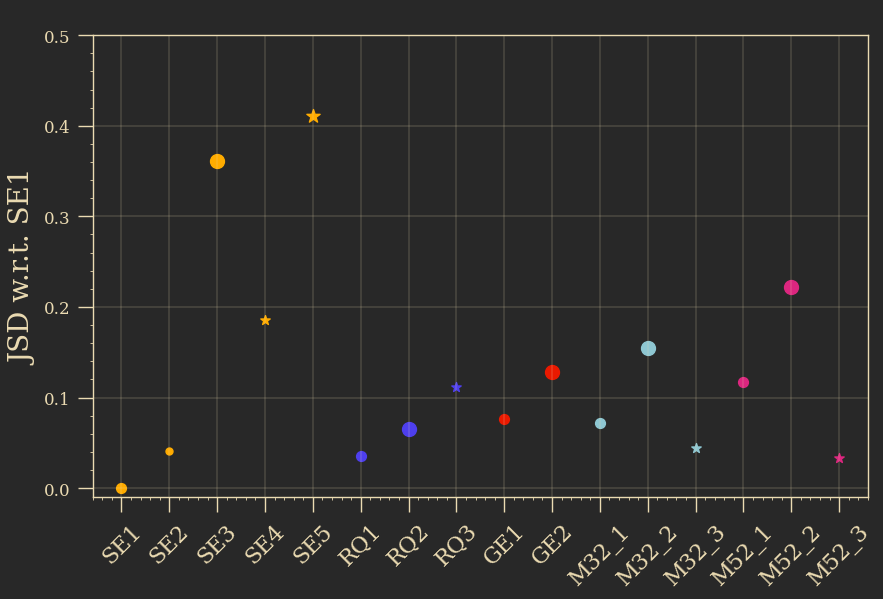

In [33]:
plt.figure(figsize=(10, 6))
plt.scatter(1, jsds[0], label='SE1', color=cols[0], s=50, marker='o')
plt.scatter(2, jsds[1], label='SE2', color=cols[0], s=25, marker='o')
plt.scatter(3, jsds[2], label='SE3', color=cols[0], s=100, marker='o')
plt.scatter(4, jsds[3], label='SE4', color=cols[0], s=50, marker='*')
plt.scatter(5, jsds[4], label='SE5', color=cols[0], s=100, marker='*')

plt.scatter(6, jsds[5], label='RQ1', color=cols[1], s=50, marker='o')
plt.scatter(7, jsds[6], label='RQ2', color=cols[1], s=100, marker='o')
plt.scatter(8, jsds[7], label='RQ3', color=cols[1], s=50, marker='*')

plt.scatter(9, jsds[8], label='GE1', color=cols[2], s=50, marker='o')
plt.scatter(10, jsds[9], label='GE2', color=cols[2], s=100, marker='o')

plt.scatter(11, jsds[10], label='M32-1', color=cols[3], s=50, marker='o')
plt.scatter(12, jsds[11], label='M32-2', color=cols[3], s=100, marker='o')
plt.scatter(13, jsds[12], label='M32-3', color=cols[3], s=50, marker='*')

plt.scatter(14, jsds[13], label='M52-1', color=cols[4], s=50, marker='o')
plt.scatter(15, jsds[14], label='M52-2', color=cols[4], s=100, marker='o')
plt.scatter(16, jsds[15], label='M52-3', color=cols[4], s=50, marker='*')

x_labels = ['SE1', 'SE2', 'SE3', 'SE4', 'SE5',
            'RQ1', 'RQ2', 'RQ3',
            'GE1', 'GE2',
            'M32_1', 'M32_2', 'M32_3',
            'M52_1', 'M52_2', 'M52_3']


plt.ylabel("JSD w.r.t. SE1", fontsize=big_fontsize, labelpad=5)
#plt.xlim(0,20)
plt.ylim(-0.01, 0.5)
plt.title(' ')
#plt.legend(loc='upper center', fontsize =solo_fontsize, ncols=4, bbox_to_anchor=(0.5, 1.5))
plt.xticks(ticks=range(1, 17), labels=x_labels, fontsize=solo_fontsize, rotation=45)

#theme.apply_transforms()
plt.show()

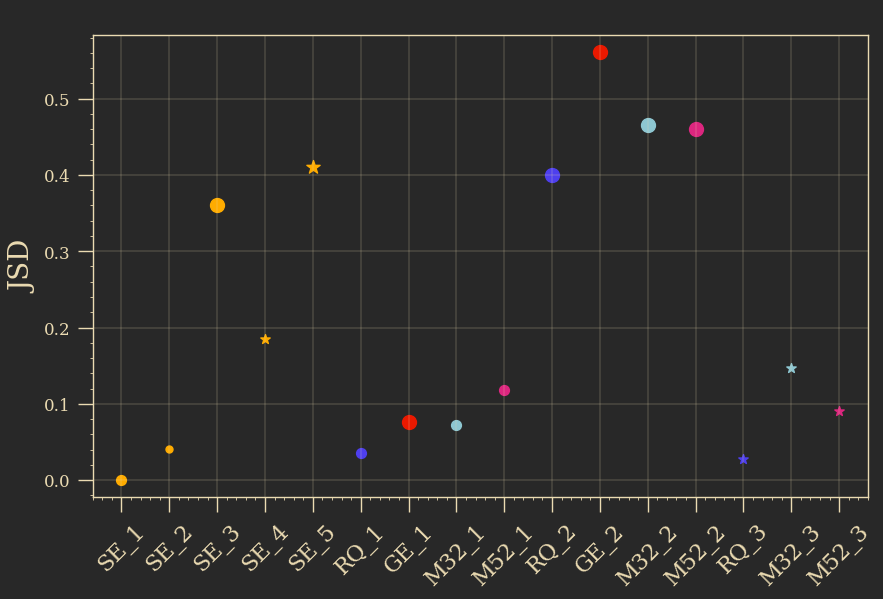

In [35]:
dfs1 = [df_se, df_se2, df_se3, df_se4, df_se5] 
    #   df_rq, df_rq2, df_rq3,
    #   df_ge, df_ge2, 
    #   df_m32, df_m322, df_m323, 
    #   df_m52, df_m522, df_m523]

jsd1 = [(jsd_compare('lambda_14', i, weighted=True)) for i in dfs1]

dfs2 = [df_rq, df_ge, df_m32, df_m52] 
jsd2 = [(jsd_compare('lambda_14', i, weighted=True)) for i in dfs2]

dfs3 = [df_rq2, df_ge2, df_m322, df_m522]
jsd3 = [(jsd_compare('lambda_14', i, weighted=True, df_control=df_se3)) for i in dfs3] 

dfs4 = [df_rq3, df_m323, df_m523]
jsd4 = [(jsd_compare('lambda_14', i, weighted=True, df_control=df_se4)) for i in dfs4]

labs = ["SE_1", "SE_2", "SE_3", "SE_4", "SE_5", 
        "RQ_1", "GE_1", "M32_1", "M52_1",
        "RQ_2", "GE_2", "M32_2", "M52_2",
        "RQ_3", "M32_3", "M52_3"]
jsds = np.concatenate([jsd1, jsd2, jsd3, jsd4])

plt.figure(figsize=(10, 6))
plt.scatter(1, jsds[0], label=labs[0], color=cols[0], s=50, marker='o')
plt.scatter(2, jsds[1], label=labs[1], color=cols[0], s=25, marker='o')
plt.scatter(3, jsds[2], label=labs[2], color=cols[0], s=100, marker='o')
plt.scatter(4, jsds[3], label=labs[3], color=cols[0], s=50, marker='*')
plt.scatter(5, jsds[4], label=labs[4], color=cols[0], s=100, marker='*')

plt.scatter(6, jsds[5], label=labs[5], color=cols[1], s=50, marker='o')
plt.scatter(7, jsds[6], label=labs[6], color=cols[2], s=100, marker='o')
plt.scatter(8, jsds[7], label=labs[7], color=cols[3], s=50, marker='o')
plt.scatter(9, jsds[8], label=labs[8], color=cols[4], s=50, marker='o')

plt.scatter(10, jsds[9], label=labs[9], color=cols[1], s=100, marker='o')
plt.scatter(11, jsds[10], label=labs[10], color=cols[2], s=100, marker='o')
plt.scatter(12, jsds[11], label=labs[11], color=cols[3], s=100, marker='o')
plt.scatter(13, jsds[12], label=labs[12], color=cols[4], s=100, marker='o')

plt.scatter(14, jsds[13], label=labs[13], color=cols[1], s=50, marker='*')
plt.scatter(15, jsds[14], label=labs[14], color=cols[3], s=50, marker='*')
plt.scatter(16, jsds[15], label=labs[15], color=cols[4], s=50, marker='*')

x_labels = ['SE1', 'SE2', 'SE3', 'SE4', 'SE5',
            'RQ1', 'RQ2', 'RQ3',
            'GE1', 'GE2',
            'M32_1', 'M32_2', 'M32_3',
            'M52_1', 'M52_2', 'M52_3']


plt.ylabel("JSD", fontsize=big_fontsize, labelpad=5)
#plt.xlim(0,20)
#plt.ylim(-0.01, 0.5)
plt.title(' ')
#plt.legend(loc='upper center', fontsize =solo_fontsize, ncols=4, bbox_to_anchor=(0.5, 1.5))
plt.xticks(ticks=range(1, 17), labels=labs, fontsize=solo_fontsize, rotation=45)

#theme.apply_transforms()
plt.show()

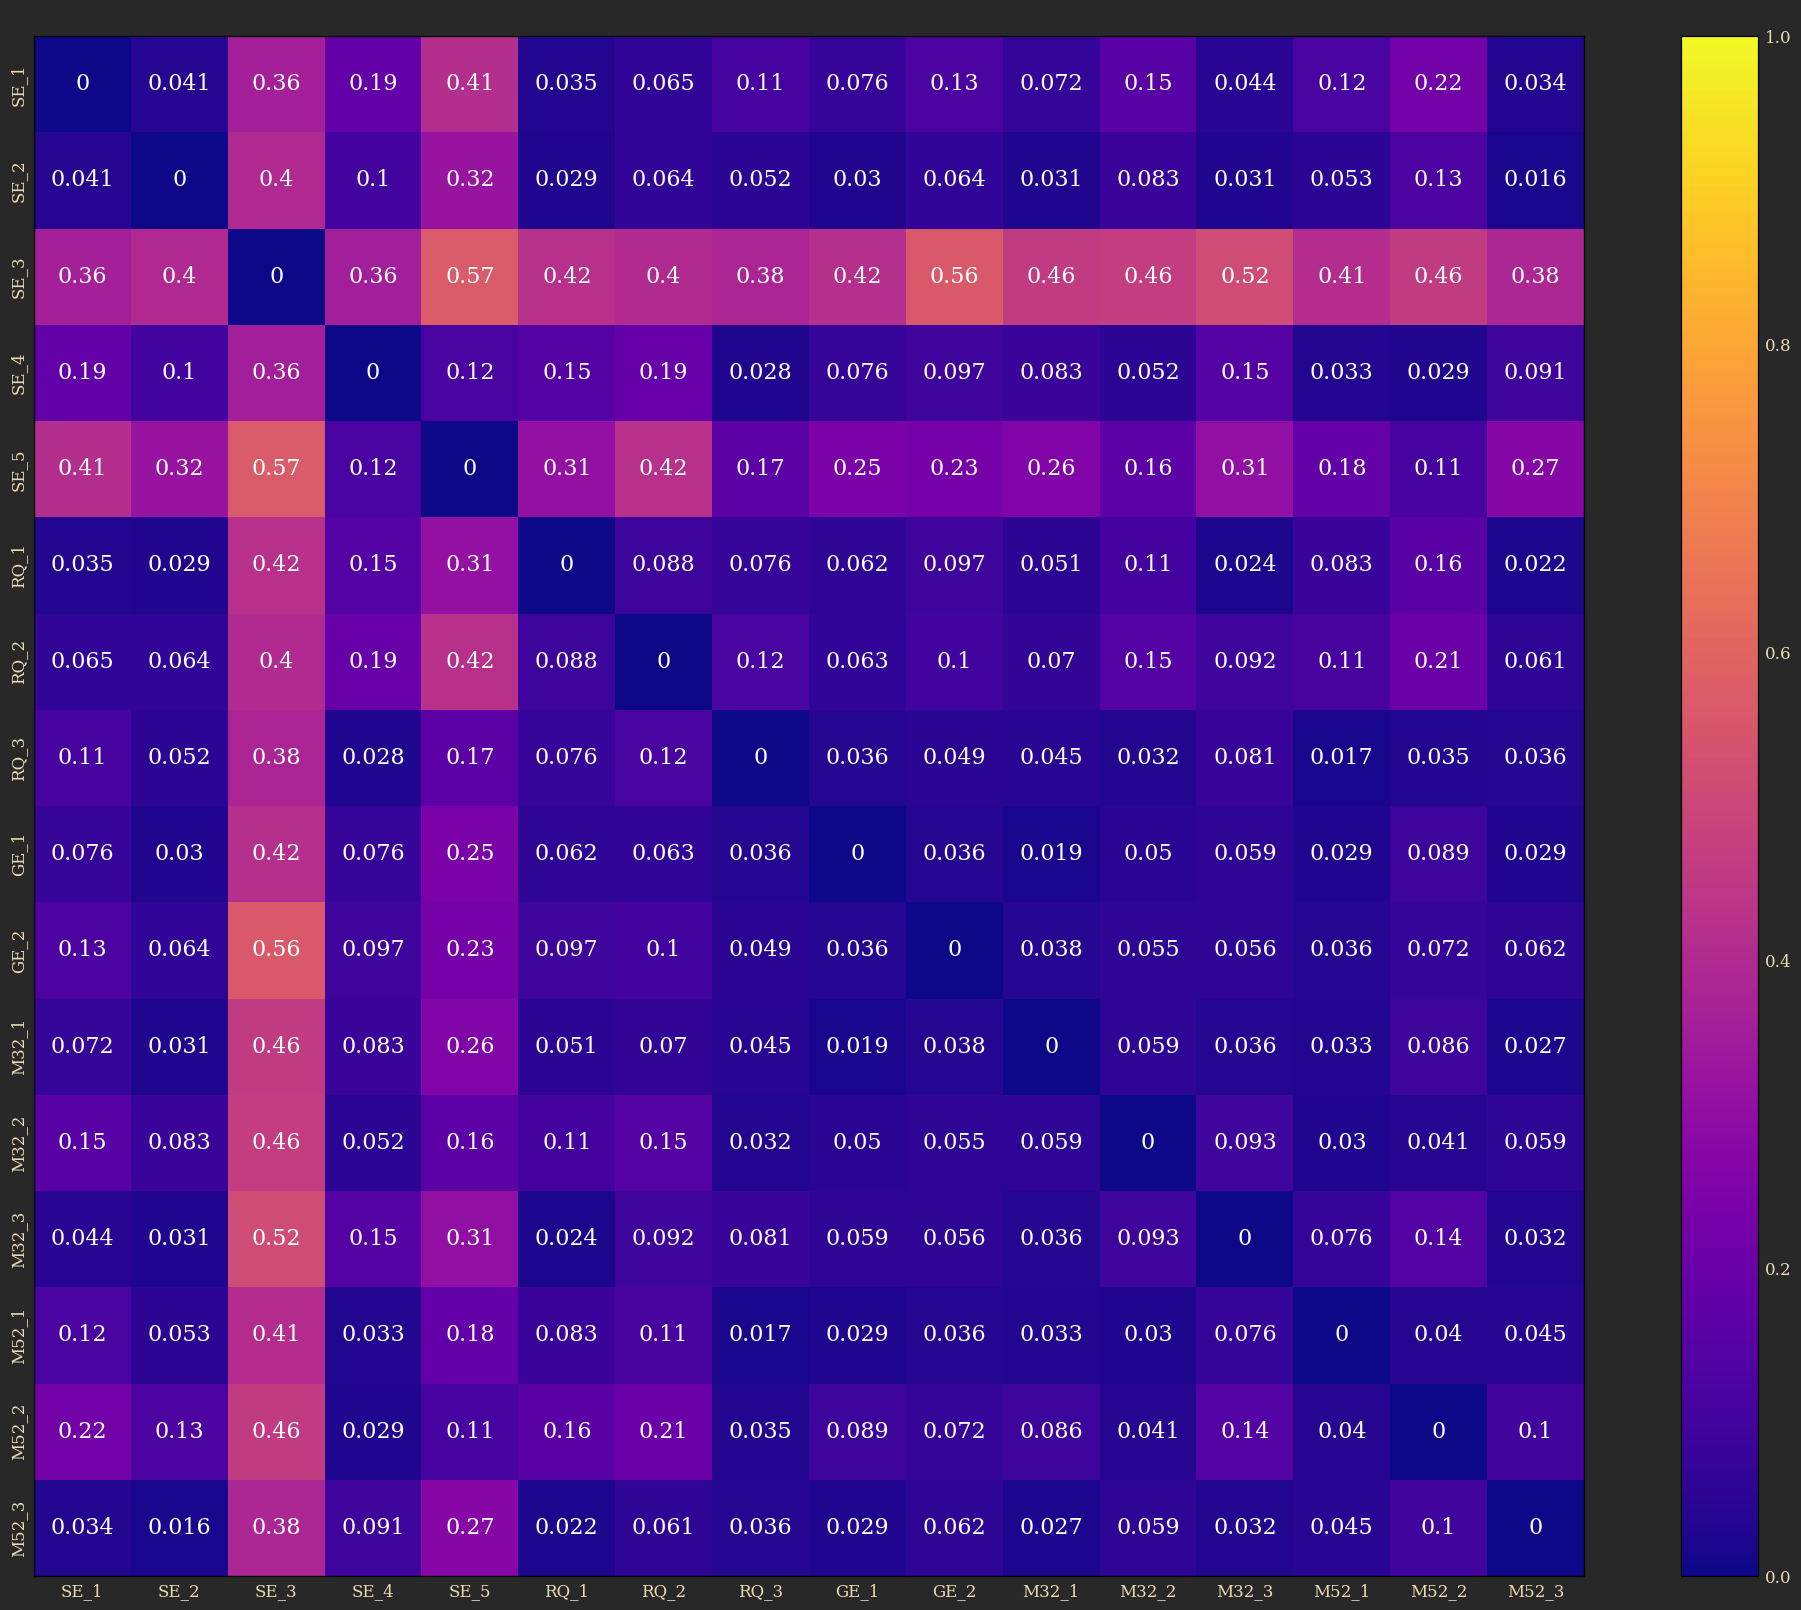

In [29]:
dfs = [df_se, df_se2, df_se3, df_se4, df_se5, 
       df_rq, df_rq2, df_rq3,
       df_ge, df_ge2, 
       df_m32, df_m322, df_m323, 
       df_m52, df_m522, df_m523]
labs = ["SE_1", "SE_2", "SE_3", "SE_4", "SE_5", "RQ_1", "RQ_2", "RQ_3", "GE_1", "GE_2", "M32_1", "M32_2", "M32_3", "M52_1", "M52_2", "M52_3"]

theme.set_grid(False)
theme.set_ticks(draw_minor=False, size_major=0)
theme.apply()
pa.plot_JSD('lambda_14', dfs, labs, title=" ", bins=40, weighted=True, size=(25, 20), annot_size=solo_fontsize)
plt.savefig(plot_dir + "kernels_JSD_posterior.png", dpi=300)
plt.show()

theme.set_grid(True, width=0.2)
theme.set_ticks(draw_minor=True, size_major=11)
theme.apply()

# Kernel Choice

## intermediate $\ell$

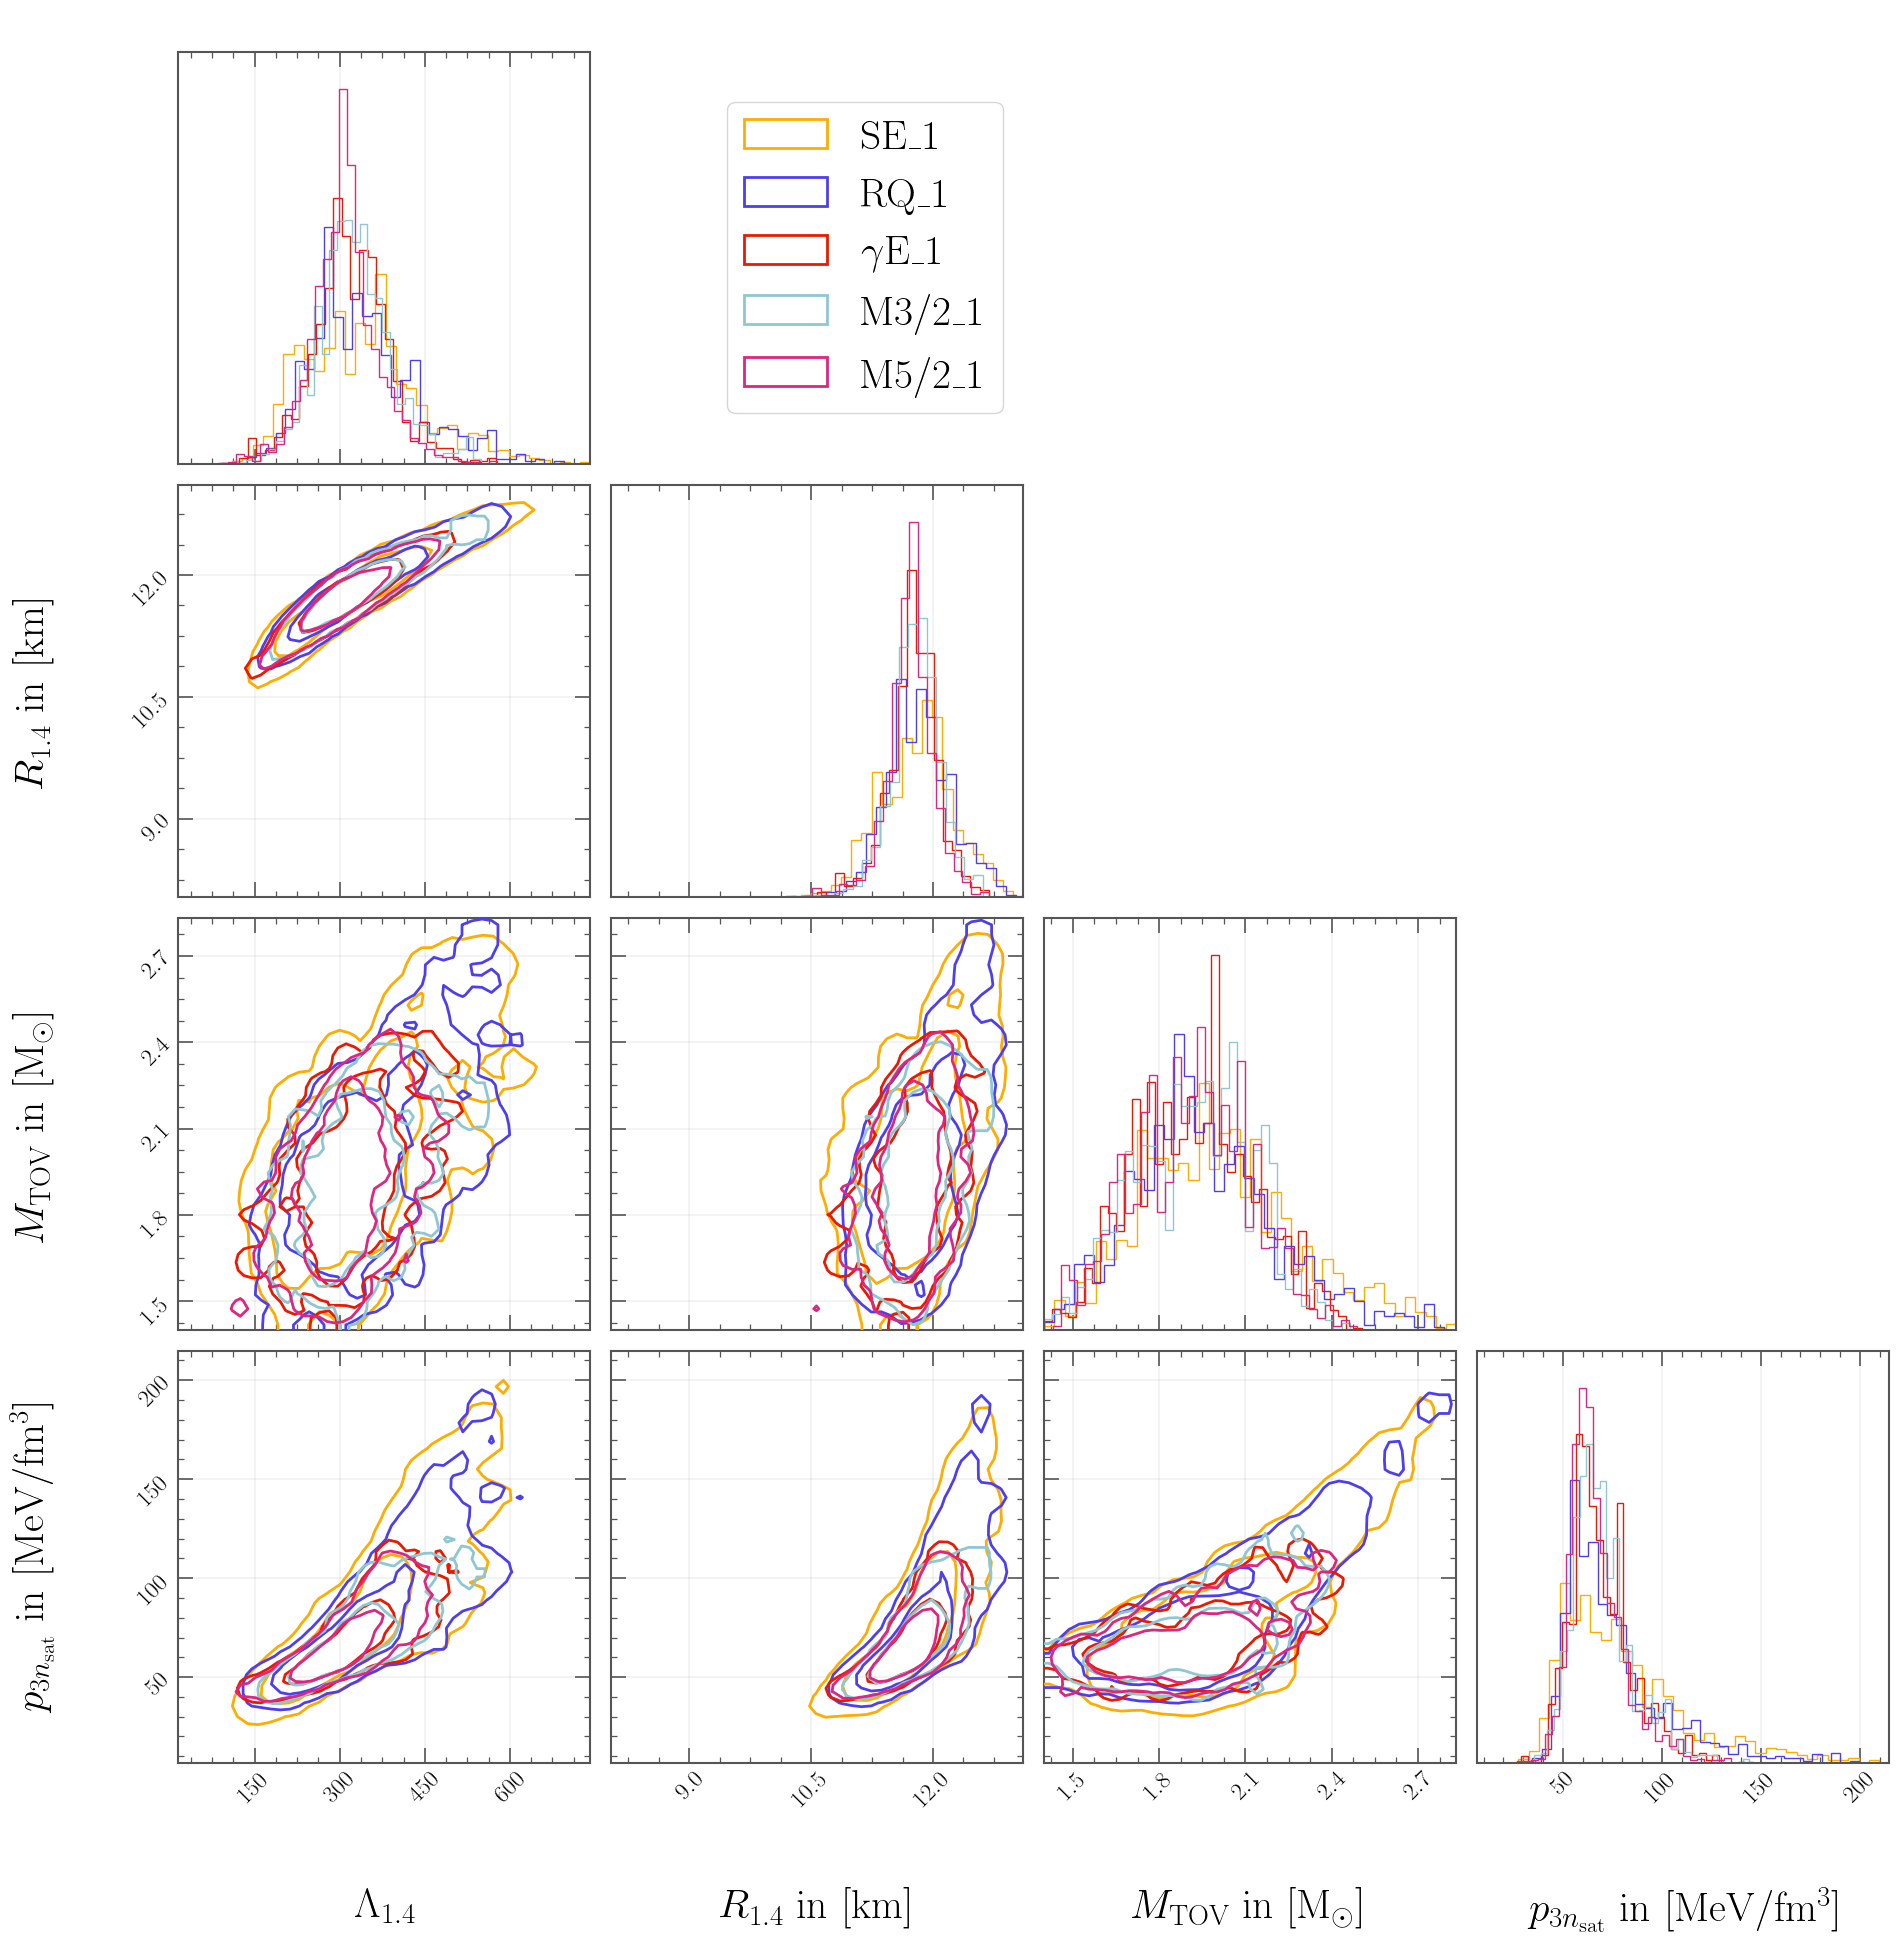

In [ ]:
labs=["SE_1", "RQ_1", "$\gamma$E_1", "M3/2_1", "M5/2_1"]
dfs = [df_se, df_rq, df_ge, df_m32, df_m52]
eoses = [eos_se, eos_rq, eos_ge, eos_m32, eos_m52]
mrs = [mr_se, mr_rq, mr_ge, mr_m32, mr_m52]


theme.apply()
pa.plot_parameters(dfs, 
                   title=" ", 
                   colours = cols,
                   labels=labs,
                   contour_fill=False,
                   which=2,
                   legend_fontsize=30,
                   axis_fontsize=30,
                   weighted=True,
                )
plt.savefig(plot_dir + "kernels_corner_posterior.png", dpi=300)
plt.show()

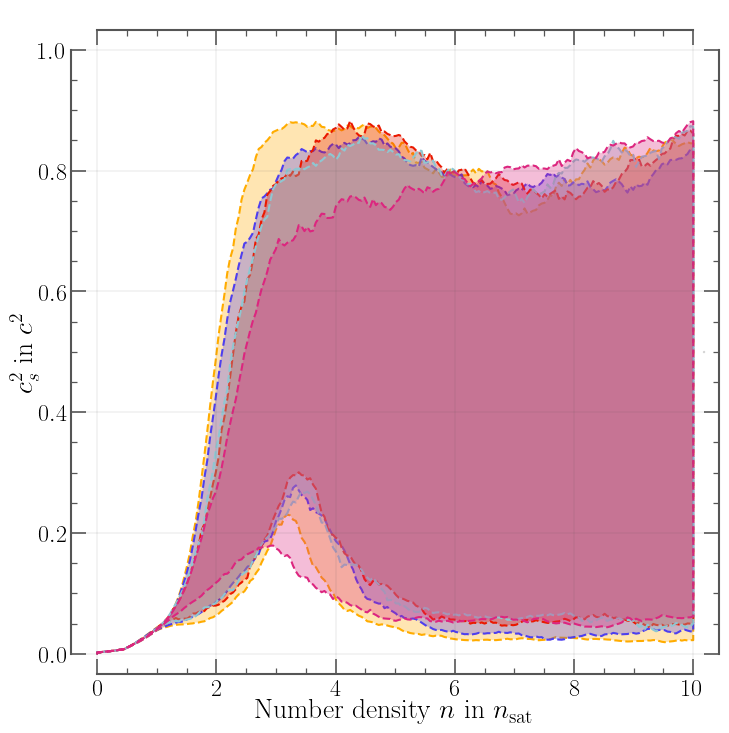

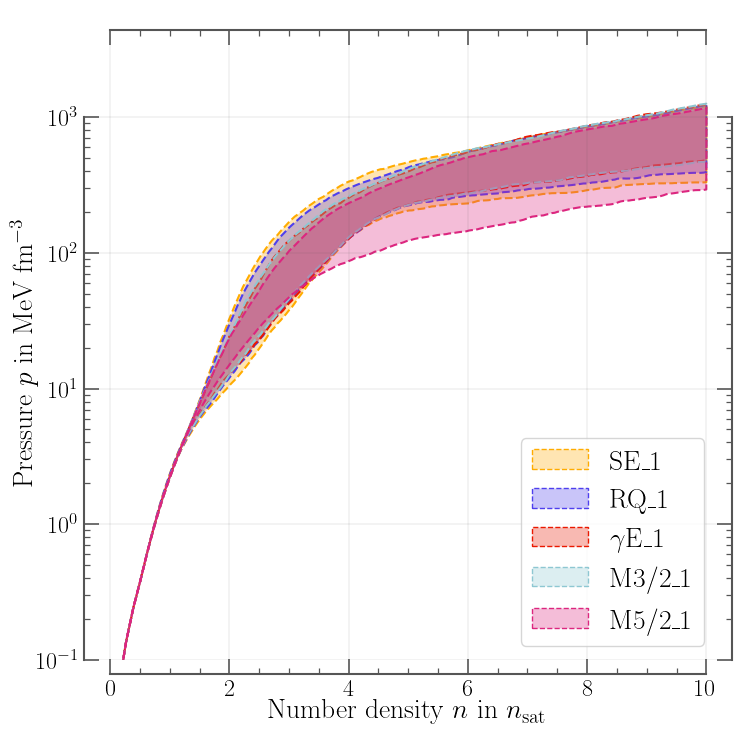

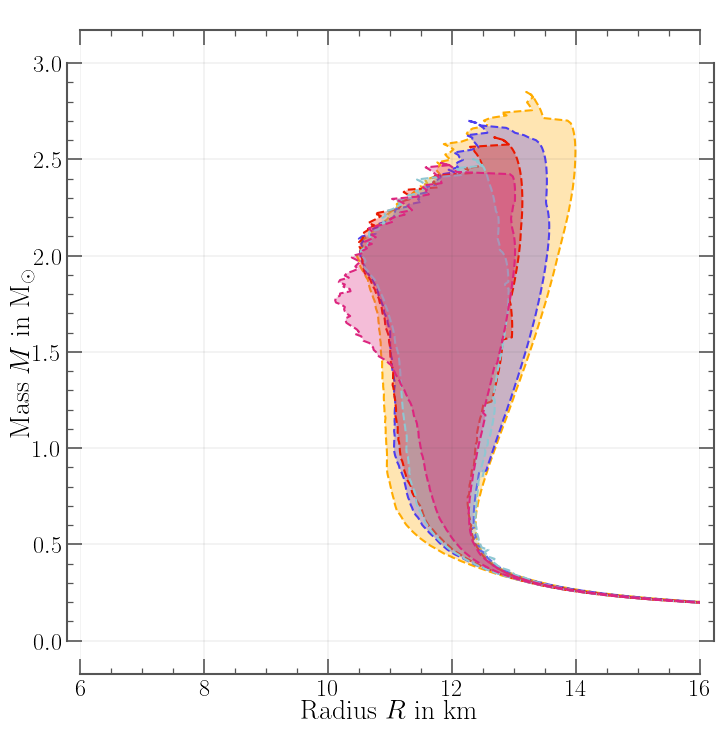

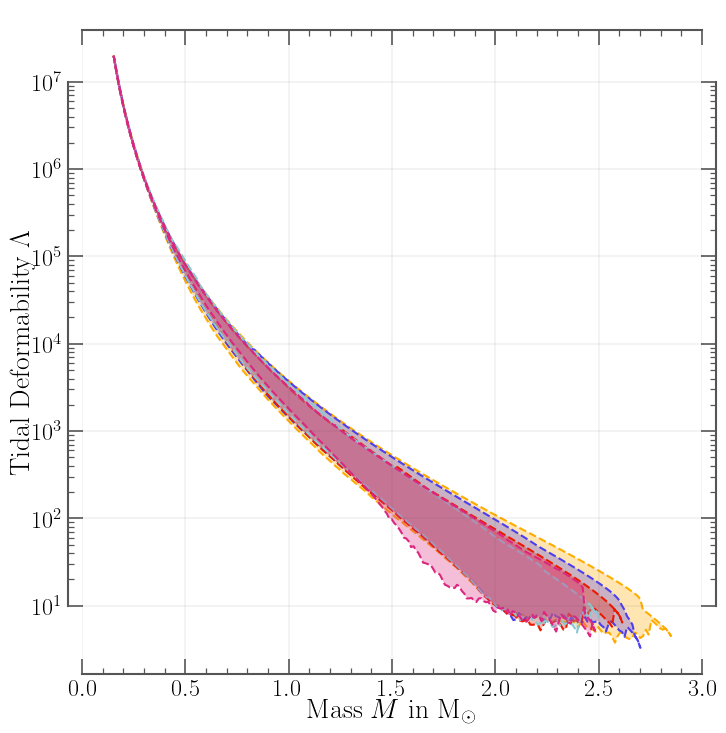

In [38]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se_post, eos_rq_post, eos_ge_post, eos_m32_post, eos_m52_post], ax1=None, ax2=ax1, 
                        mr_list=[mr_se_post, mr_rq_post, mr_ge_post, mr_m32_post, mr_m52_post], 
                        labels=None, colours=cols, plot_alone="cs2", plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_rq, weight_ge, weight_m32, weight_m52]
                        )
plt.title(" ")
plt.ylim(-0.01, 1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_cs2_posterior.png", dpi=300)

plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se_post, eos_rq_post, eos_ge_post, eos_m32_post, eos_m52_post], ax1=ax1, 
                        mr_list=[mr_se_post, mr_rq_post, mr_ge_post, mr_m32_post, mr_m52_post], 
                        labels=["SE_1", "RQ_1", "$\gamma$E_1", "M3/2_1", "M5/2_1"],
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize,
                        weights=[weight_se, weight_rq, weight_ge, weight_m32, weight_m52]
                        )


plt.ylim(0.1,)
plt.yscale('log')
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_p_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


pa.plot_eos_comparisons([eos_se_post, eos_rq_post, eos_ge_post, eos_m32_post, eos_m52_post], ax1=None, ax3=ax1, 
                        mr_list=[mr_se_post, mr_rq_post, mr_ge_post, mr_m32_post, mr_m52_post],  
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_rq, weight_ge, weight_m32, weight_m52]
                        )

plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_mr_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


pa.plot_eos_comparisons([eos_se_post, eos_rq_post, eos_ge_post, eos_m32_post, eos_m52_post], ax1=None, ax4=ax1, 
                        mr_list=[mr_se_post, mr_rq_post, mr_ge_post, mr_m32_post, mr_m52_post], 
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_rq, weight_ge, weight_m32, weight_m52]
                        )

ax1.set_xlim(0, 3)
ax1.set_yscale('log')
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_mt_posterior.png", dpi=300)
plt.show()

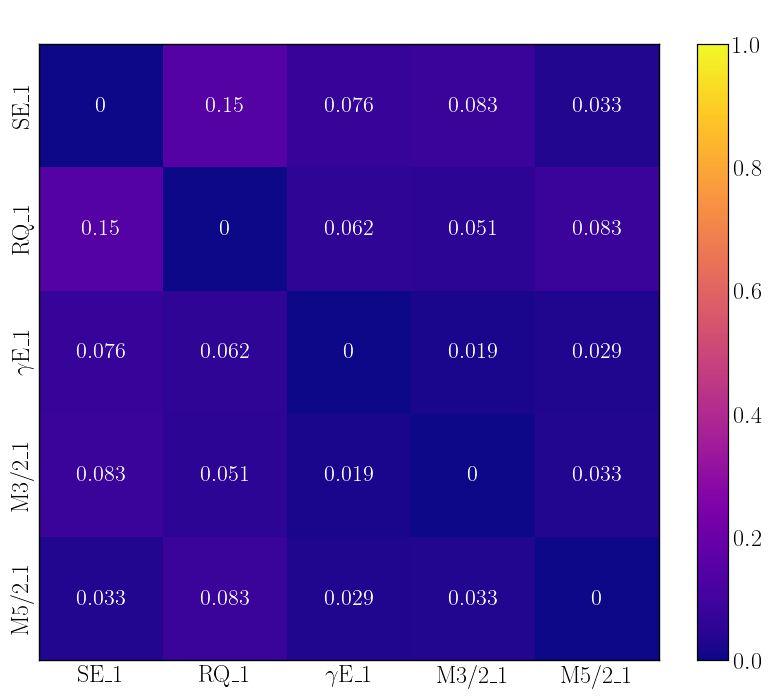

In [39]:
labs=["SE_1", "RQ_1", "$\gamma$E_1", "M3/2_1", "M5/2_1"]
dfs = [df_se4, df_rq, df_ge, df_m32, df_m52]
theme.set_grid(False)
theme.set_ticks(draw_minor=False, size_major=0)
theme.apply()
pa.plot_JSD('lambda_14', dfs, labs, title=" ", bins=40, weighted=True, size=(10, 8), annot_size=solo_fontsize)
plt.savefig(plot_dir + "kernels_JSD_posterior.png", dpi=300)
plt.show()

theme.set_grid(True, width=0.2)
theme.set_ticks(draw_minor=True, size_major=11)
theme.apply()

In [ ]:
labs=["SE_1", "RQ_1", "$\gamma$E_1", "M3/2_1", "M5/2_1"]
dfs = [df_se4, df_rq, df_ge, df_m32, df_m52]
pa.JSD_average('lambda_14', dfs, labs, bins=40, weighted=True) 

Average JSD: 0.06153564472272236


0.06153564472272236

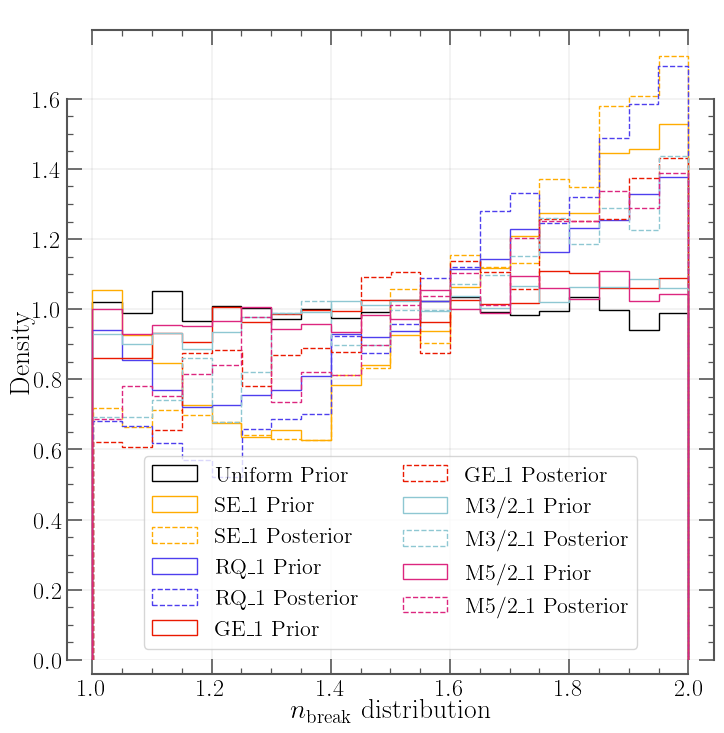

In [ ]:
plt.figure(figsize=(8, 8))
nbreak_plot(['SE_10ns_1', 'RQ_10ns_1', 'GE_10ns_1', 'M32_10ns_1', 'M52_10ns_1'], colours=cols, labs=['SE_1', 'RQ_1', 'GE_1', 'M3/2_1', 'M5/2_1'], 
            posterior_dfs=[df_se, df_rq, df_ge, df_m32, df_m52],
            plot_unif_prior=True, 
            legend_fontsize=big_fontsize, axis_fontsize=big_fontsize)
plt.legend(loc='lower center', ncols=2, fontsize=solo_fontsize)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_nbreak_posterior.png", dpi=300)
plt.show()

## large $\ell$

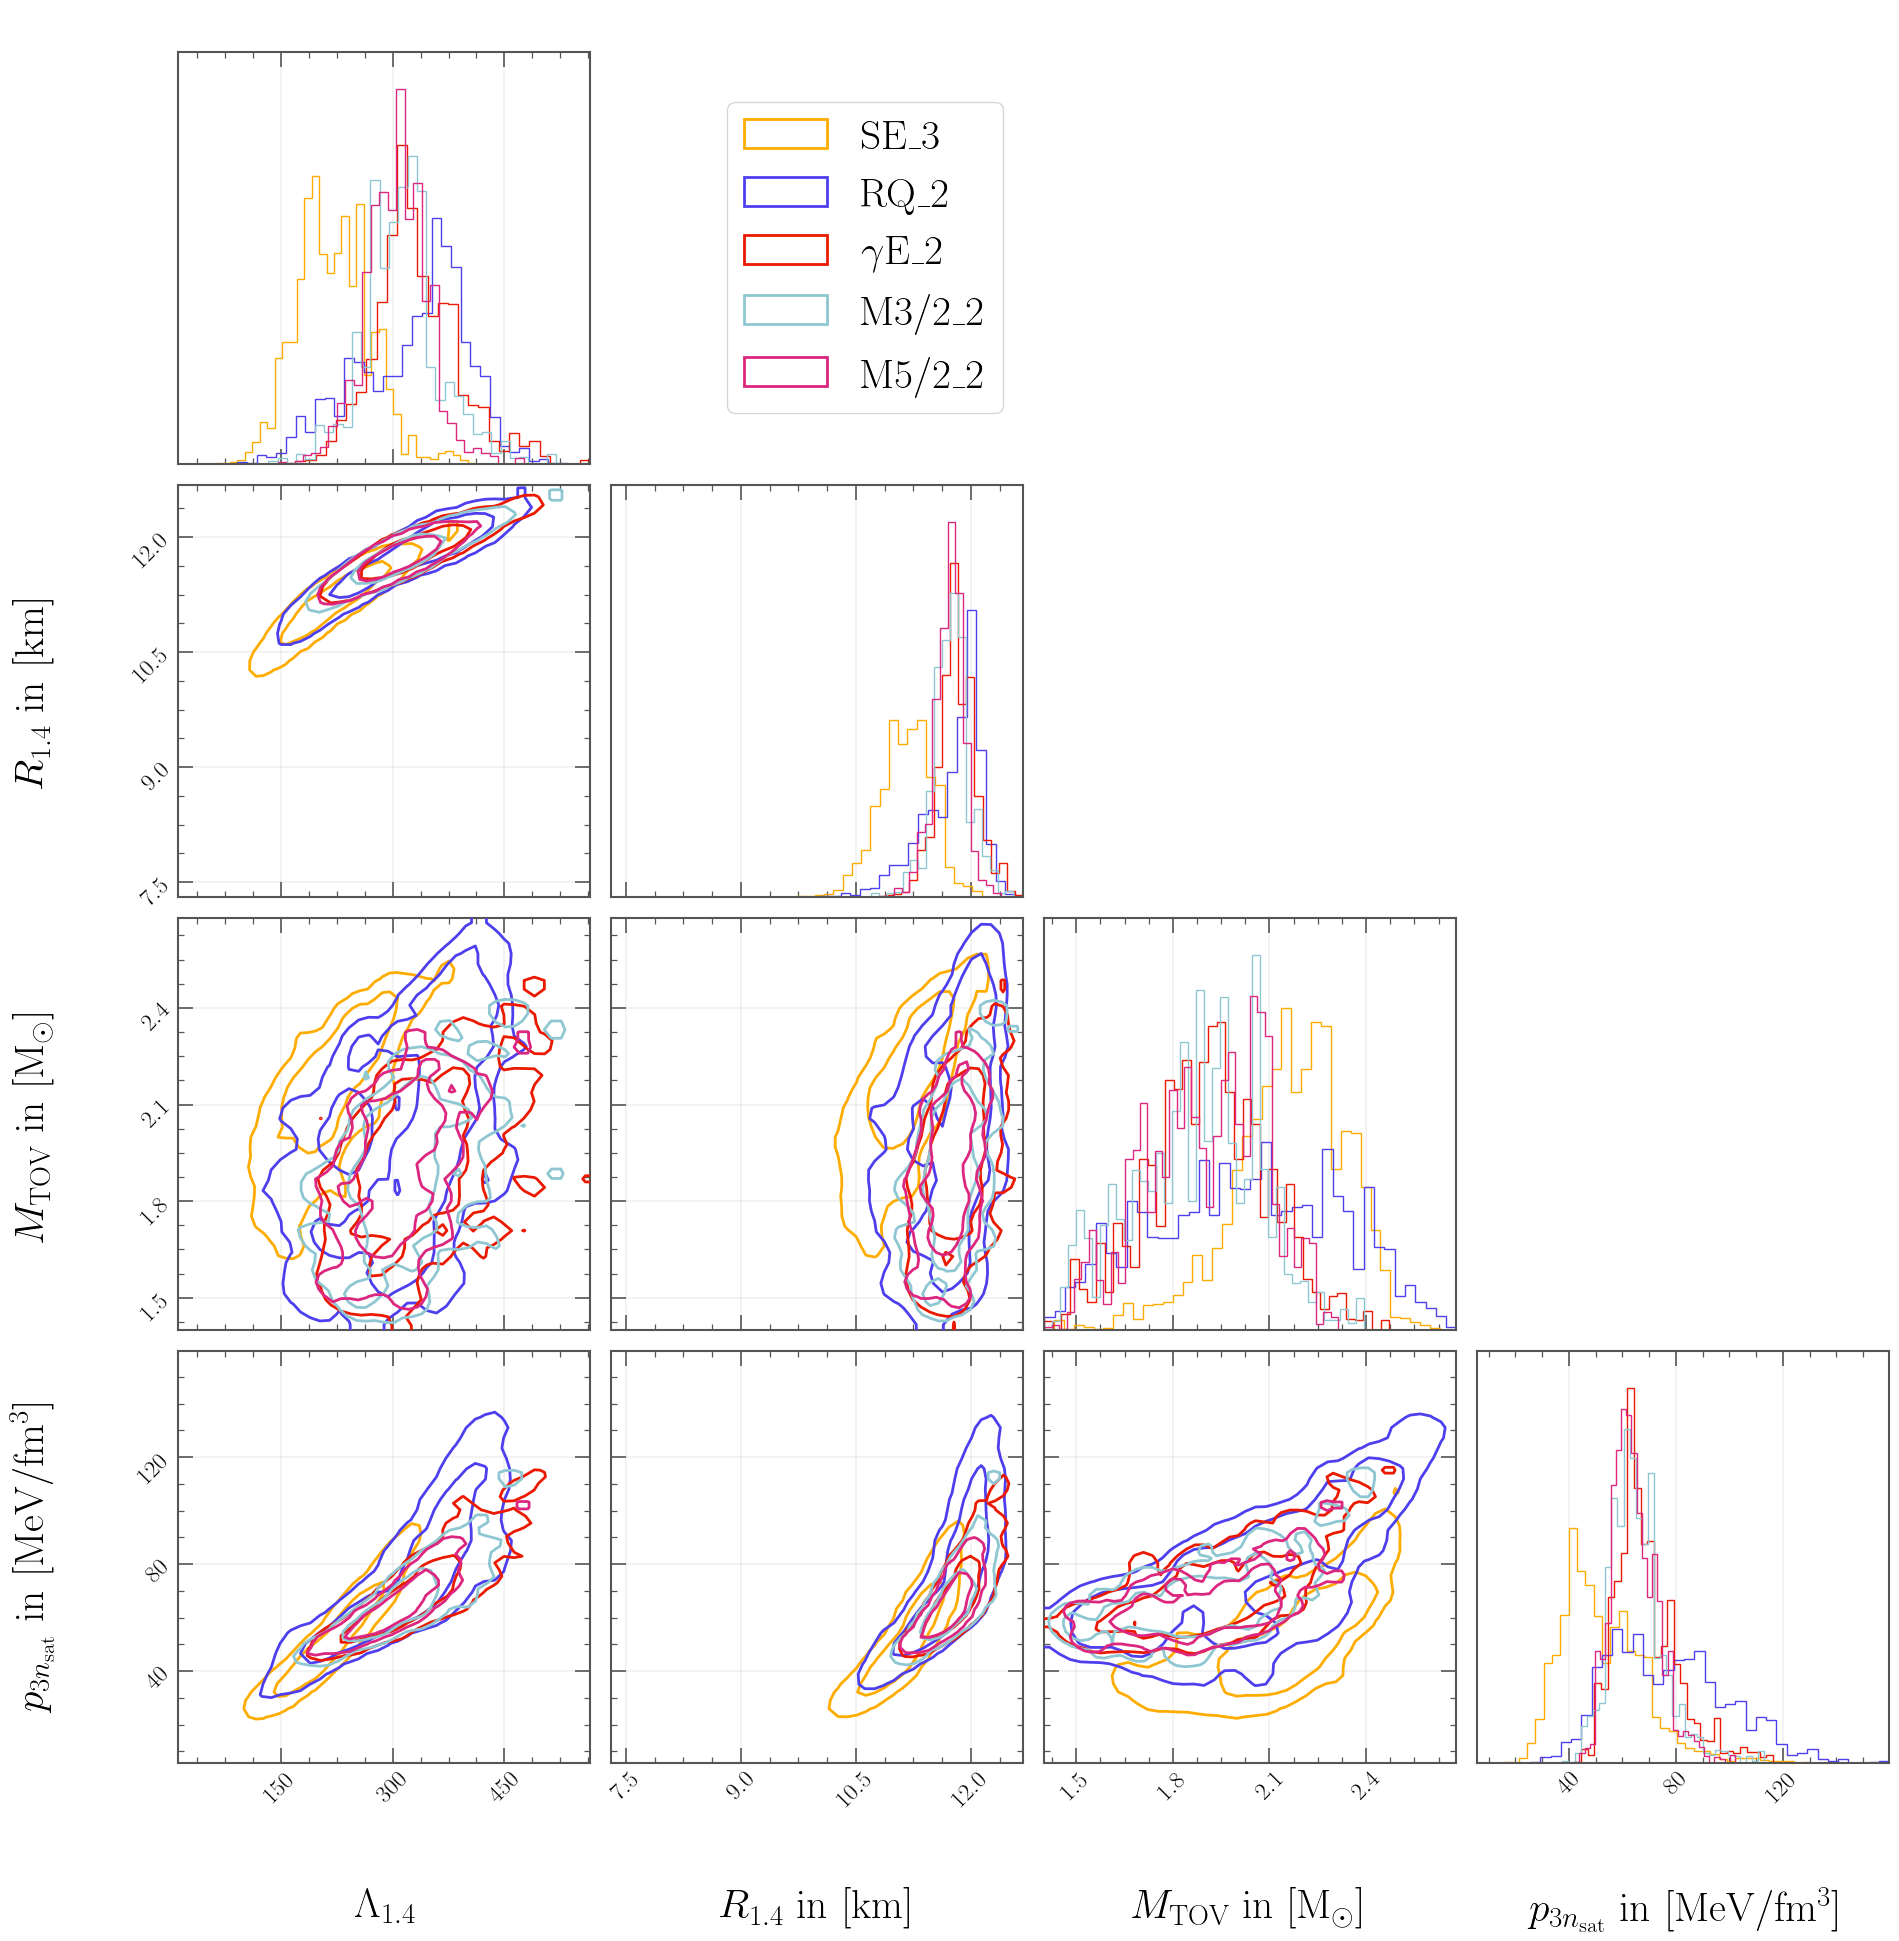

In [ ]:
labs=["SE_3", "RQ_2", "$\gamma$E_2", "M3/2_2", "M5/2_2"]
dfs = [df_se3, df_rq2, df_ge2, df_m322, df_m522]
eoses = [eos_se3, eos_rq2, eos_ge2, eos_m322, eos_m522]
mrs = [mr_se3, mr_rq2, mr_ge2, mr_m322, mr_m522]


theme.apply()
pa.plot_parameters(dfs, 
                   title=" ", 
                   colours = cols,
                   labels=labs,
                   contour_fill=False,
                   which=2,
                   legend_fontsize=30,
                   axis_fontsize=30,
                   weighted=True
                )
plt.savefig(plot_dir + "kernels_large_corner_posterior.png", dpi=300)
plt.show()

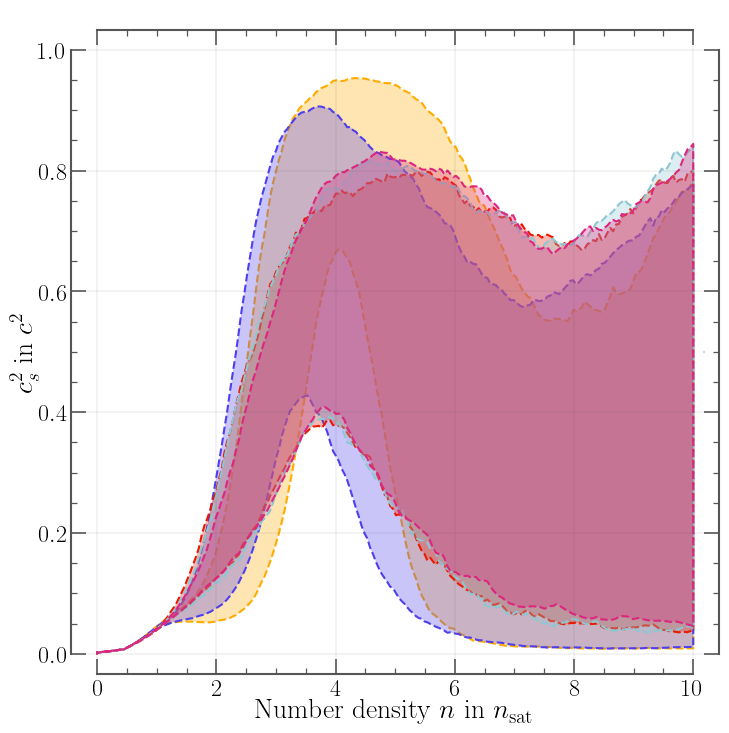

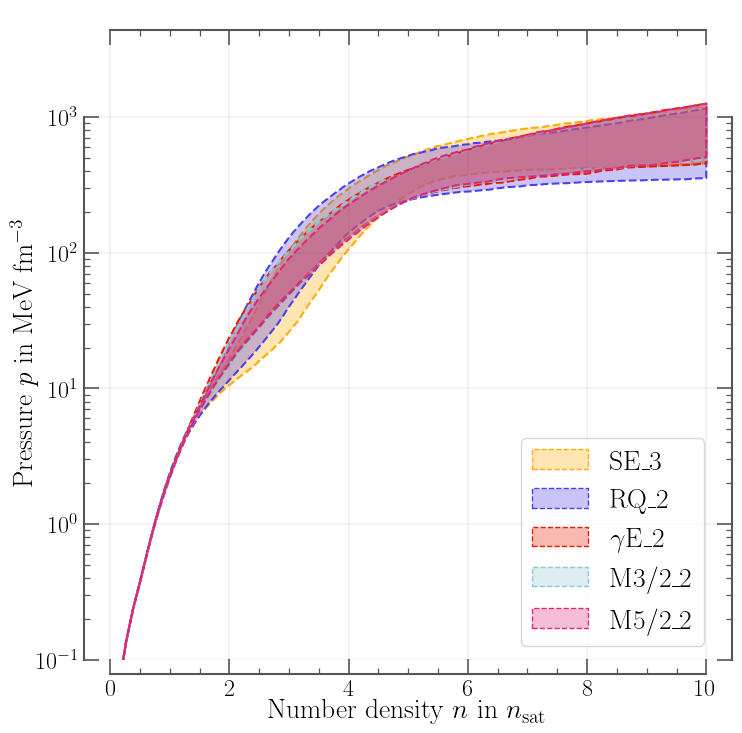

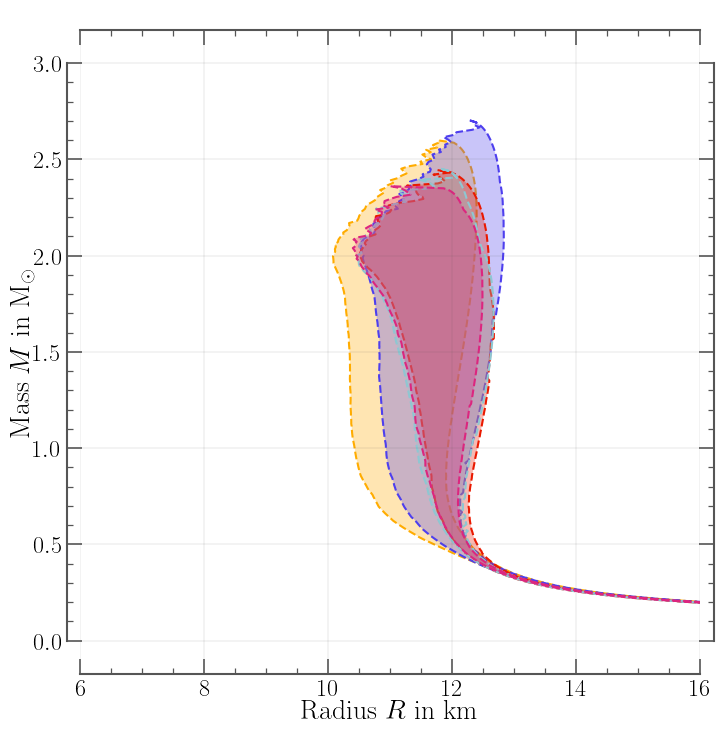

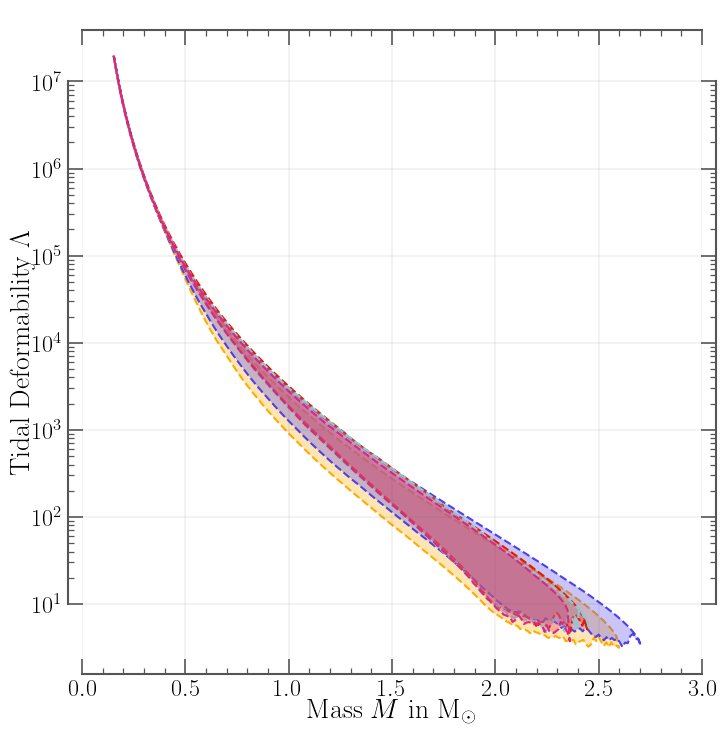

In [40]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se3_post, eos_rq2_post, eos_ge2_post, eos_m322_post, eos_m522_post], ax1=None, ax2=ax1, 
                        mr_list=[mr_se3_post, mr_rq2_post, mr_ge2_post, mr_m322_post, mr_m522_post], 
                        labels=None, colours=cols, plot_alone="cs2", plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se3, weight_rq2, weight_ge2, weight_m322, weight_m522]
                        )
plt.title(" ")
plt.ylim(-0.01, 1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_large_cs2_posterior.png", dpi=300)

plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se3_post, eos_rq2_post, eos_ge2_post, eos_m322_post, eos_m522_post], ax1=ax1, 
                        mr_list=[mr_se3_post, mr_rq2_post, mr_ge2_post, mr_m322_post, mr_m522_post], 
                        labels=["SE_3", "RQ_2", "$\gamma$E_2", "M3/2_2", "M5/2_2"],
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize,
                        weights=[weight_se3, weight_rq2, weight_ge2, weight_m322, weight_m522]
                        )


plt.ylim(0.1,)
plt.yscale('log')
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_large_p_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


plt.plot([], [], color='silver', alpha=1, label='Samples')

pa.plot_eos_comparisons([eos_se3_post, eos_rq2_post, eos_ge2_post, eos_m322_post, eos_m522_post], ax1=None, ax3=ax1, 
                        mr_list=[mr_se3_post, mr_rq2_post, mr_ge2_post, mr_m322_post, mr_m522_post],  
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se3, weight_rq2, weight_ge2, weight_m322, weight_m522]
                        )

plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_large_mr_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


pa.plot_eos_comparisons([eos_se3_post, eos_rq2_post, eos_ge2_post, eos_m322_post, eos_m522_post], ax1=None, ax4=ax1, 
                        mr_list=[mr_se3_post, mr_rq2_post, mr_ge2_post, mr_m322_post, mr_m522_post], 
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se3, weight_rq2, weight_ge2, weight_m322, weight_m522]
                        )
                        
ax1.set_xlim(0, 3)
ax1.set_yscale('log')
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_large_mt_posterior.png", dpi=300)
plt.show()

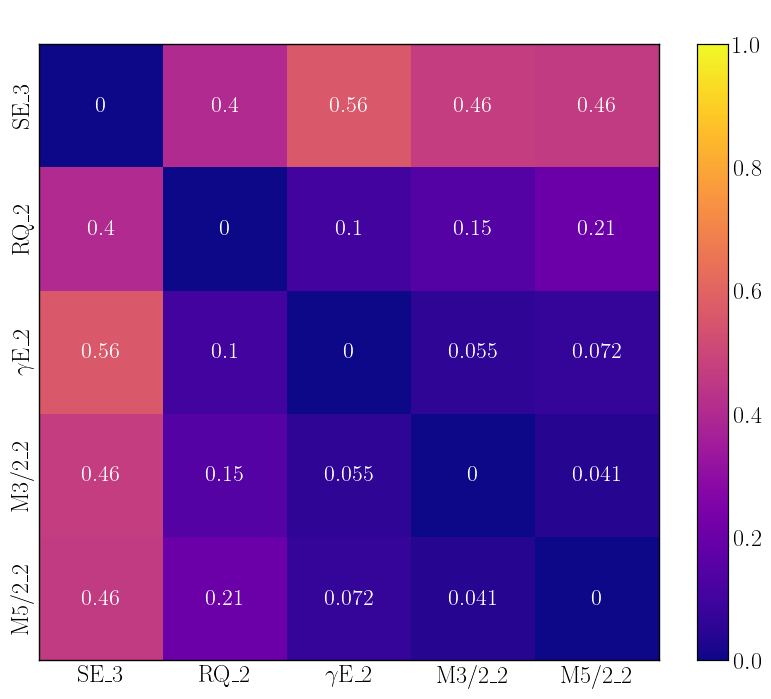

In [41]:
labs=["SE_3", "RQ_2", "$\gamma$E_2", "M3/2_2", "M5/2_2"]
dfs = [df_se3, df_rq2, df_ge2, df_m322, df_m522]
theme.set_grid(False)
theme.set_ticks(draw_minor=False, size_major=0)
theme.apply()
pa.plot_JSD('lambda_14', dfs, labs, title=" ", bins=40, weighted=True, size=(10, 8))
plt.savefig(plot_dir + "kernels_large_JSD_posterior.png", dpi=300)
plt.show()

theme.set_grid(True, width=0.2)
theme.set_ticks(draw_minor=True, size_major=11)
theme.apply()

In [10]:
labs=["SE_3", "RQ_2", "$\gamma$E_2", "M3/2_2", "M5/2_2"]
dfs = [df_se3, df_rq2, df_ge2, df_m322, df_m522]
pa.JSD_average('lambda_14', dfs, bins=40, weighted=True) 

Average JSD: 0.25078246522517345


0.25078246522517345

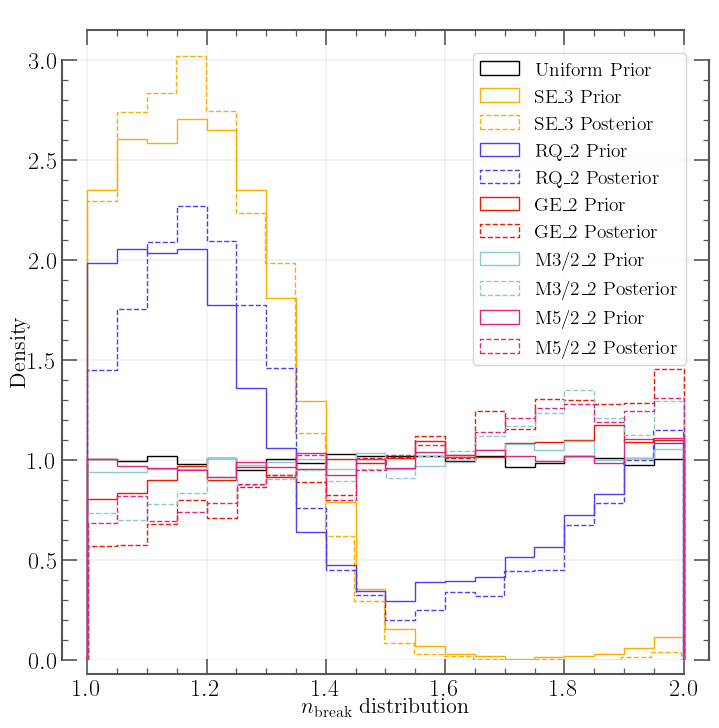

In [ ]:
plt.figure(figsize=(8, 8))
nbreak_plot(['SE_10ns_3', 'RQ_10ns_2', 'GE_10ns_2', 'M32_10ns_2', 'M52_10ns_2'], colours=cols, labs=['SE_3', 'RQ_2', 'GE_2', 'M3/2_2', 'M5/2_2'], 
            posterior_dfs=[df_se, df_rq, df_ge, df_m32, df_m52],
            plot_unif_prior=True, 
            legend_fontsize=big_fontsize, axis_fontsize=solo_fontsize)
plt.legend(loc='upper right', ncols=1, fontsize=solo_fontsize-2)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_nbreak_posterior.png", dpi=300)
plt.show()

## cGP different kernels

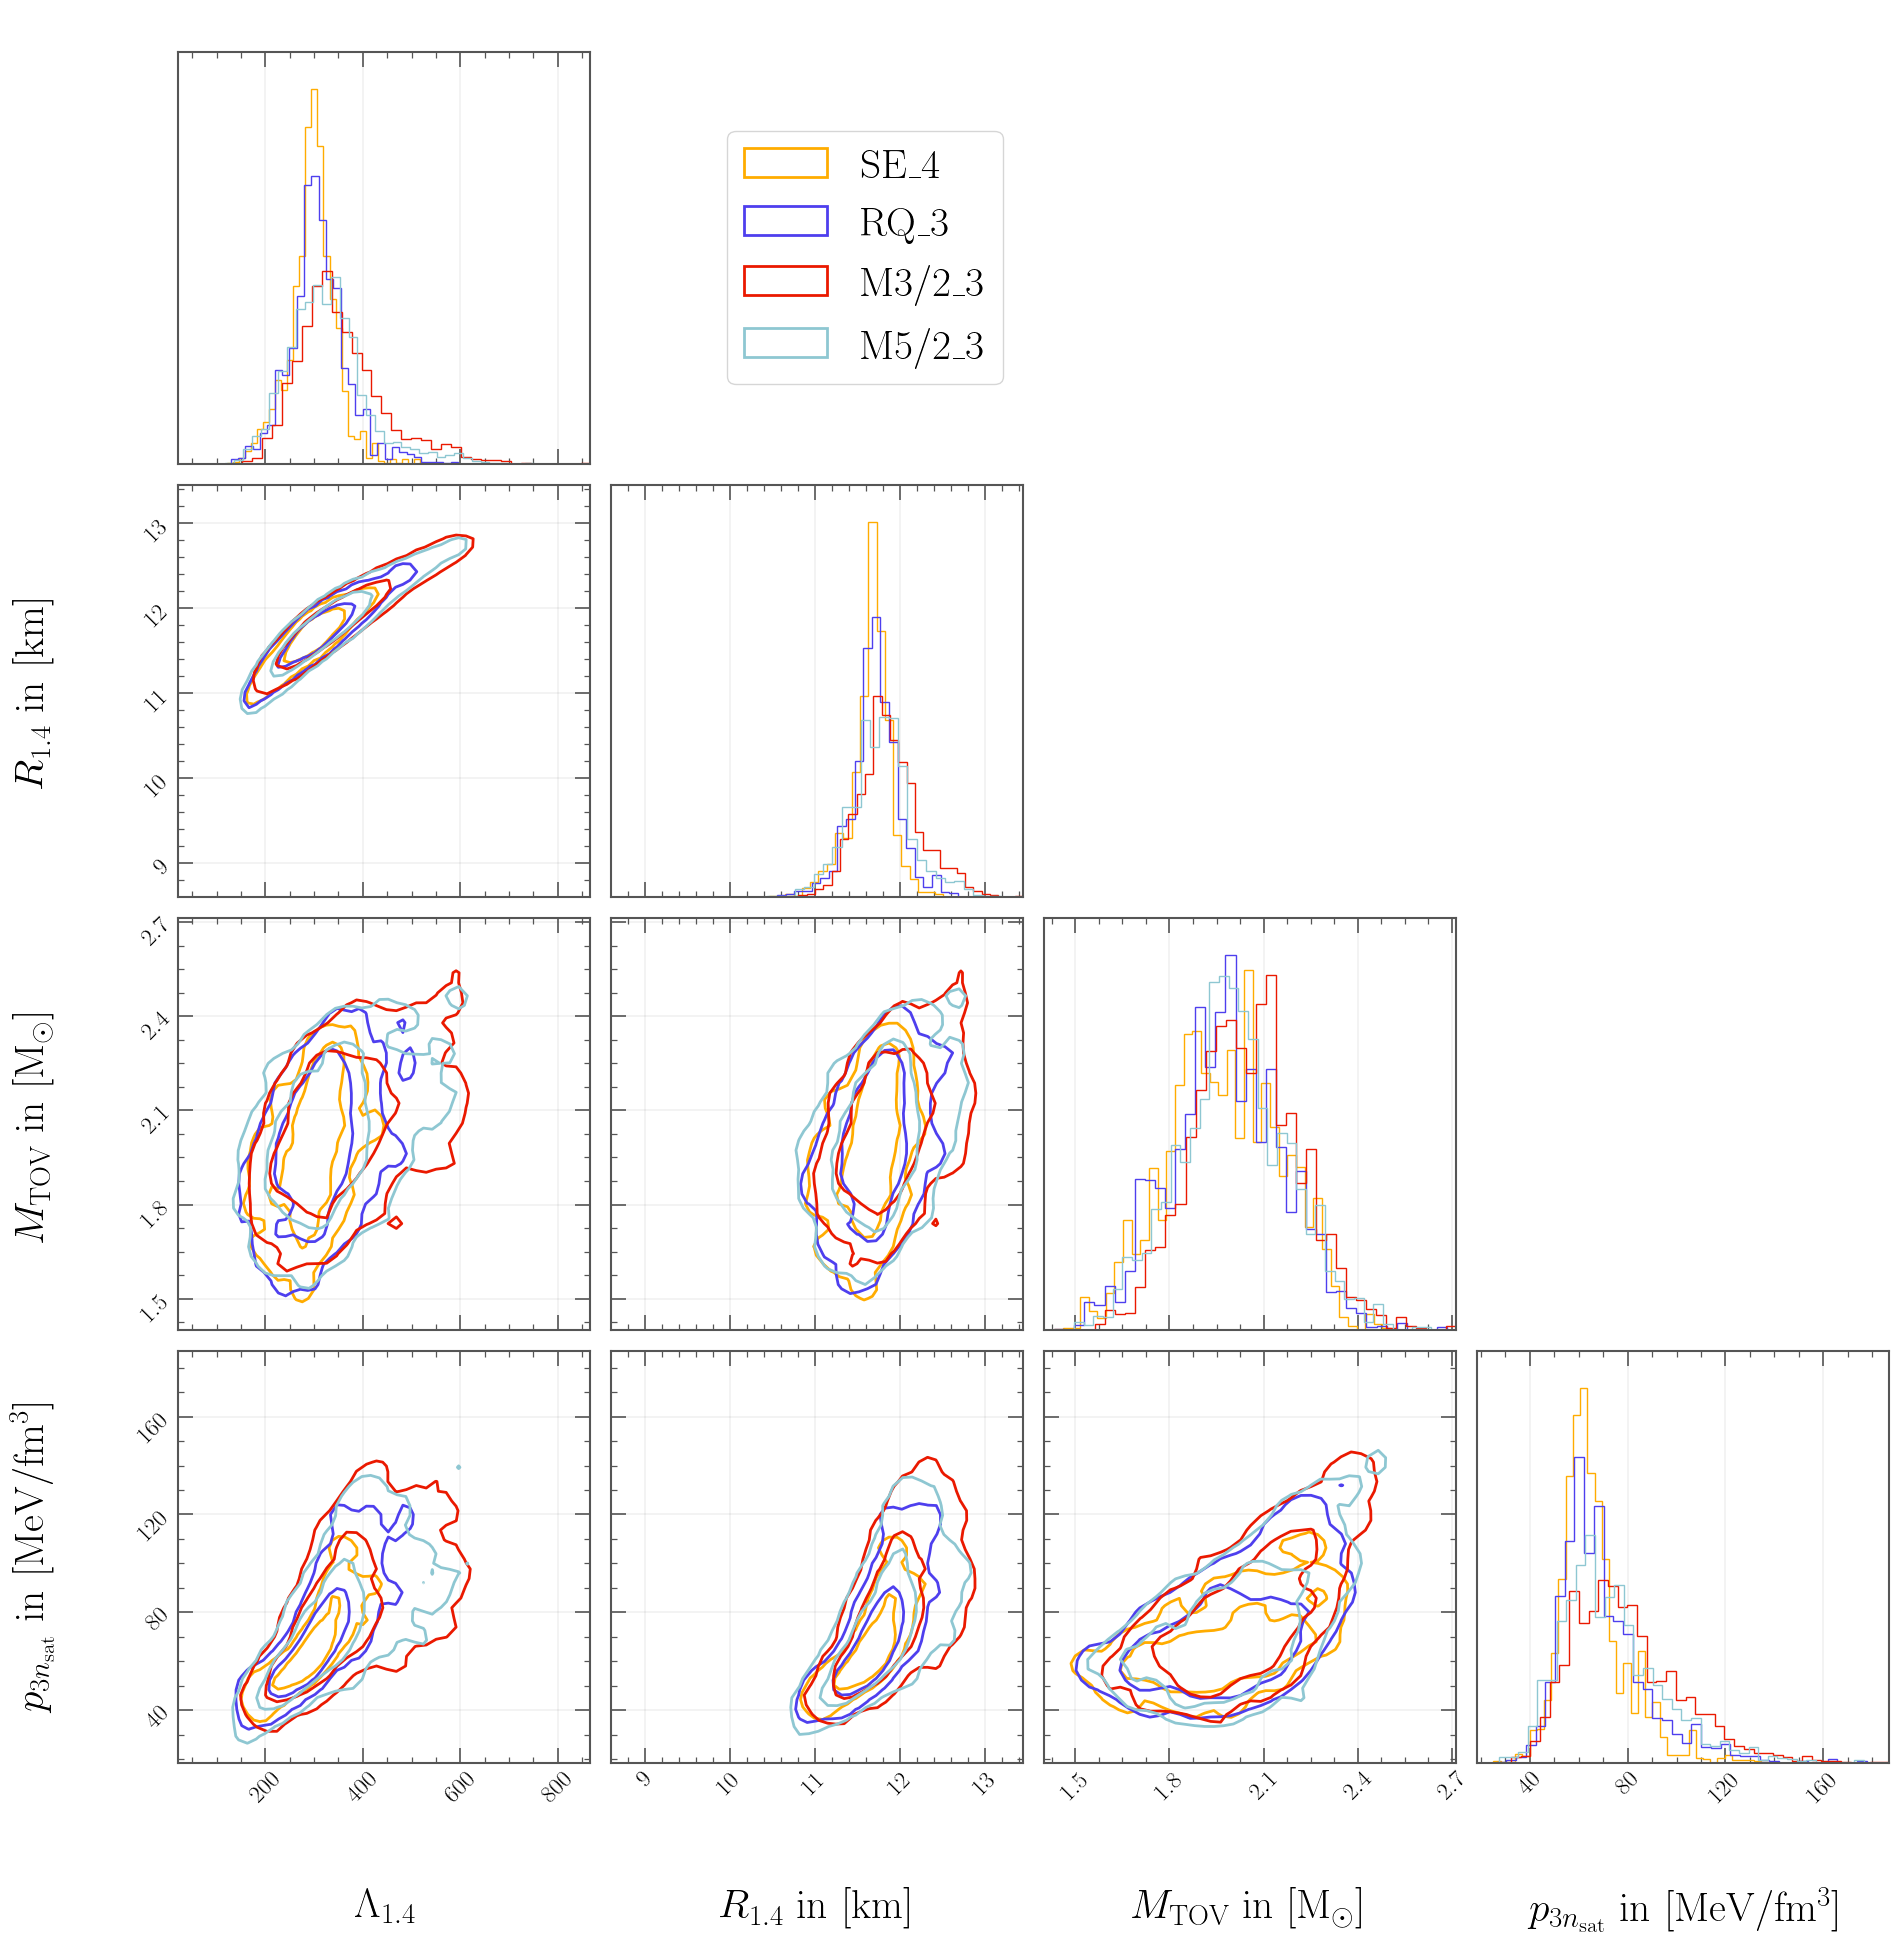

In [ ]:
labs=["SE_4", "RQ_3", "M3/2_3", "M5/2_3"]
dfs = [df_se4, df_rq3, df_m323, df_m523]
eoses = [eos_se4, eos_rq3, eos_m323, eos_m523]
mrs = [mr_se4, mr_rq3, mr_m323, mr_m523]


theme.apply()
pa.plot_parameters(dfs, 
                   title=" ", 
                   colours = cols,
                   labels=labs,
                   contour_fill=False,
                   which=2,
                   legend_fontsize=30,
                   axis_fontsize=30,
                   weighted=True
                )
plt.savefig(plot_dir + "cgp_kernel_corner_posterior.png", dpi=300)
plt.show()

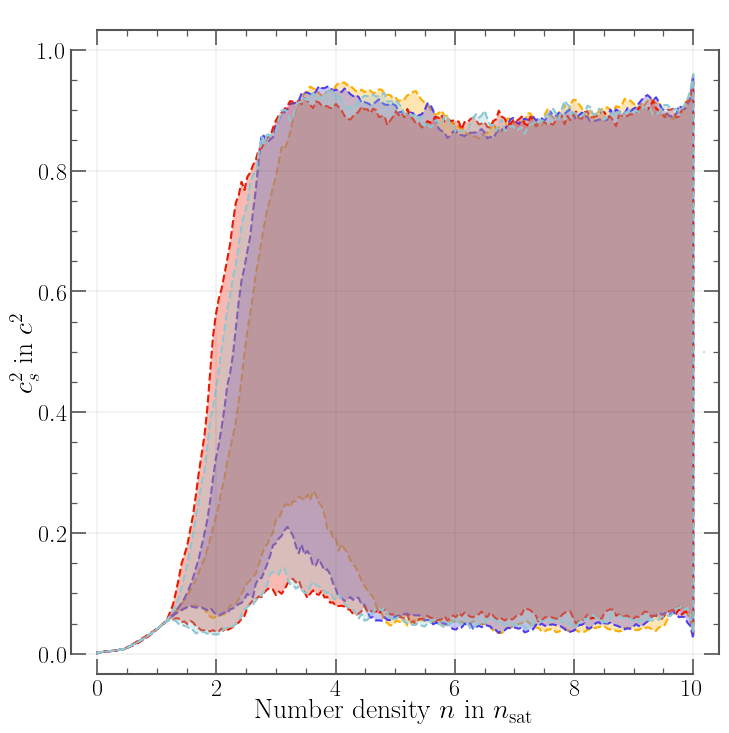

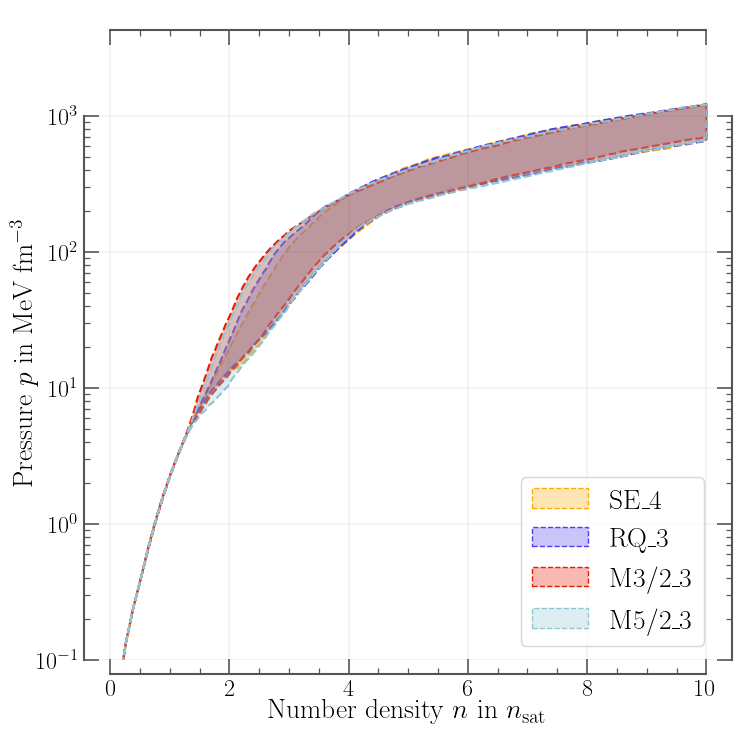

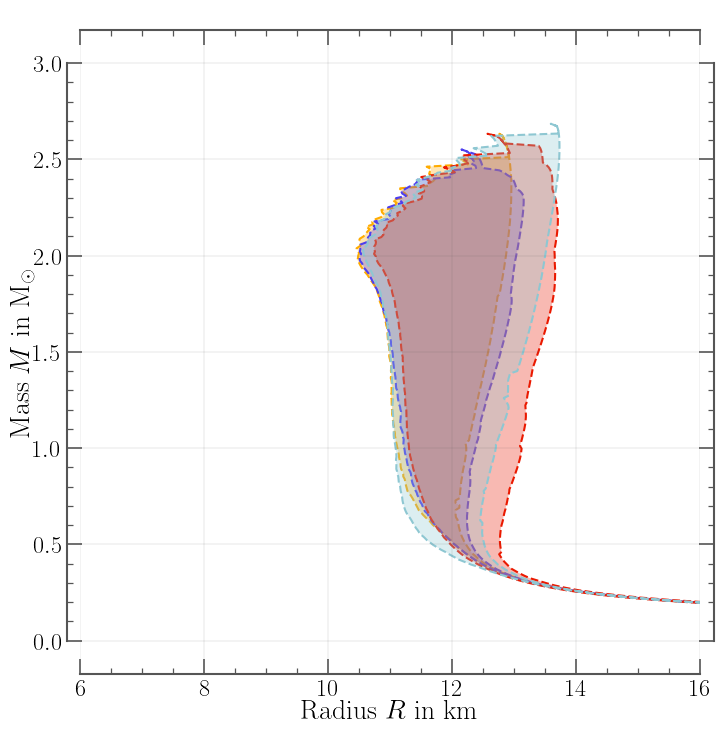

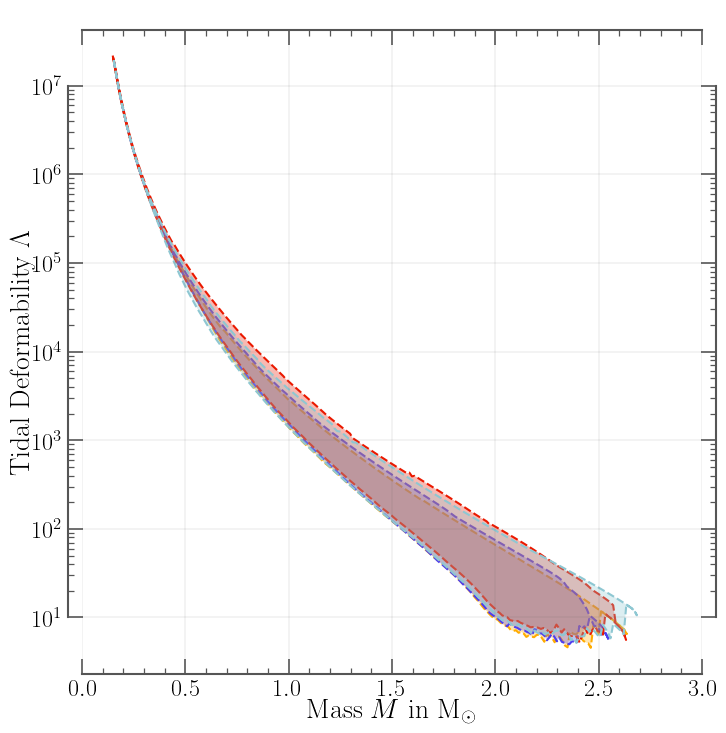

In [42]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se4_post, eos_rq3_post, eos_m323_post, eos_m523_post], ax1=None, ax2=ax1, 
                        mr_list=[mr_se4_post, mr_rq3_post, mr_m323_post, mr_m523_post], 
                        labels=None, colours=cols, plot_alone="cs2", plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se4, weight_rq3, weight_m323, weight_m523]
                        )
plt.title(" ")
plt.ylim(-0.01, 1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_cgp_cs2_posterior.png", dpi=300)

plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se4_post, eos_rq3_post, eos_m323_post, eos_m523_post], ax1=ax1, 
                        mr_list=[mr_se4_post, mr_rq3_post, mr_m323_post, mr_m523_post], 
                        labels=["SE_4", "RQ_3", "M3/2_3", "M5/2_3"],
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize,
                        weights=[weight_se4, weight_rq3, weight_m323, weight_m523])


plt.ylim(0.1,)
plt.yscale('log')
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_cgp_p_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


plt.plot([], [], color='silver', alpha=1, label='Samples')

pa.plot_eos_comparisons([eos_se4_post, eos_rq3_post, eos_m323_post, eos_m523_post], ax1=None, ax3=ax1, 
                        mr_list=[mr_se4_post, mr_rq3_post, mr_m323_post, mr_m523_post],  
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se4, weight_rq3, weight_m323, weight_m523])

plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_cgp_mr_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


pa.plot_eos_comparisons([eos_se4_post, eos_rq3_post, eos_m323_post, eos_m523_post], ax1=None, ax4=ax1, 
                        mr_list=[mr_se4_post, mr_rq3_post, mr_m323_post, mr_m523_post], 
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se4, weight_rq3, weight_m323, weight_m523])

ax1.set_xlim(0, 3)
ax1.set_yscale('log')
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "kernels_cgp_mt_posterior.png", dpi=300)
plt.show()

In [ ]:
labs=["SE_4", "RQ_3", "M3/2_3", "M5/2_3"]
dfs = [df_se4, df_rq3, df_m323, df_m523]
pa.JSD_average('lambda_14', dfs, labs, bins=40, weighted=True) 

Average JSD: 0.06904012401686636


0.06904012401686636

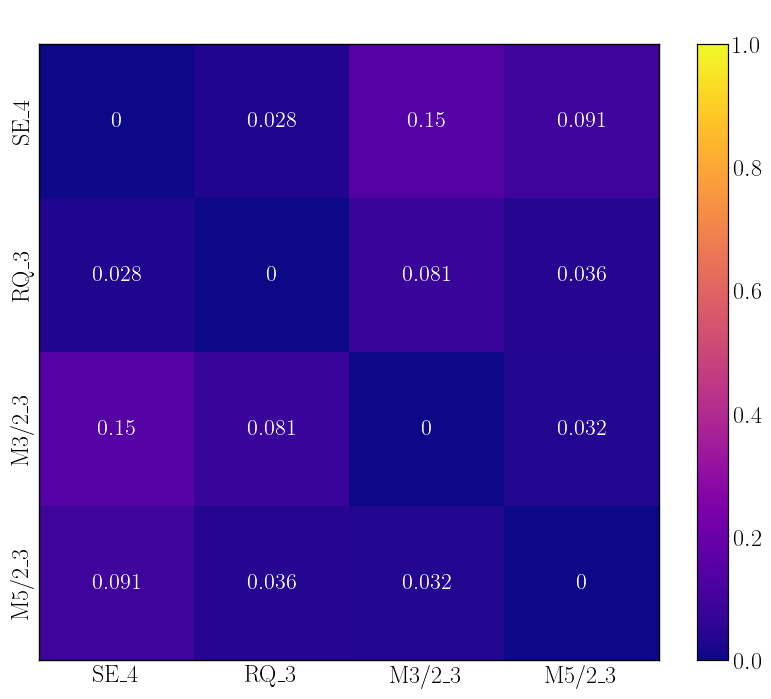

In [43]:
labs=["SE_4", "RQ_3", "M3/2_3", "M5/2_3"]
dfs = [df_se4, df_rq3, df_m323, df_m523]
theme.set_grid(False)
theme.set_ticks(draw_minor=False, size_major=0)
theme.apply()
pa.plot_JSD('lambda_14', dfs, labs, title=" ", bins=40, weighted=True, size=(10, 8))
plt.savefig(plot_dir + "cgp_kernel_JSD_posterior.png", dpi=300)
plt.show()
theme.set_grid(True, width=0.2)
theme.set_ticks(draw_minor=True, size_major=11)
theme.apply()

# Lengthscale distribution and bounding Choice

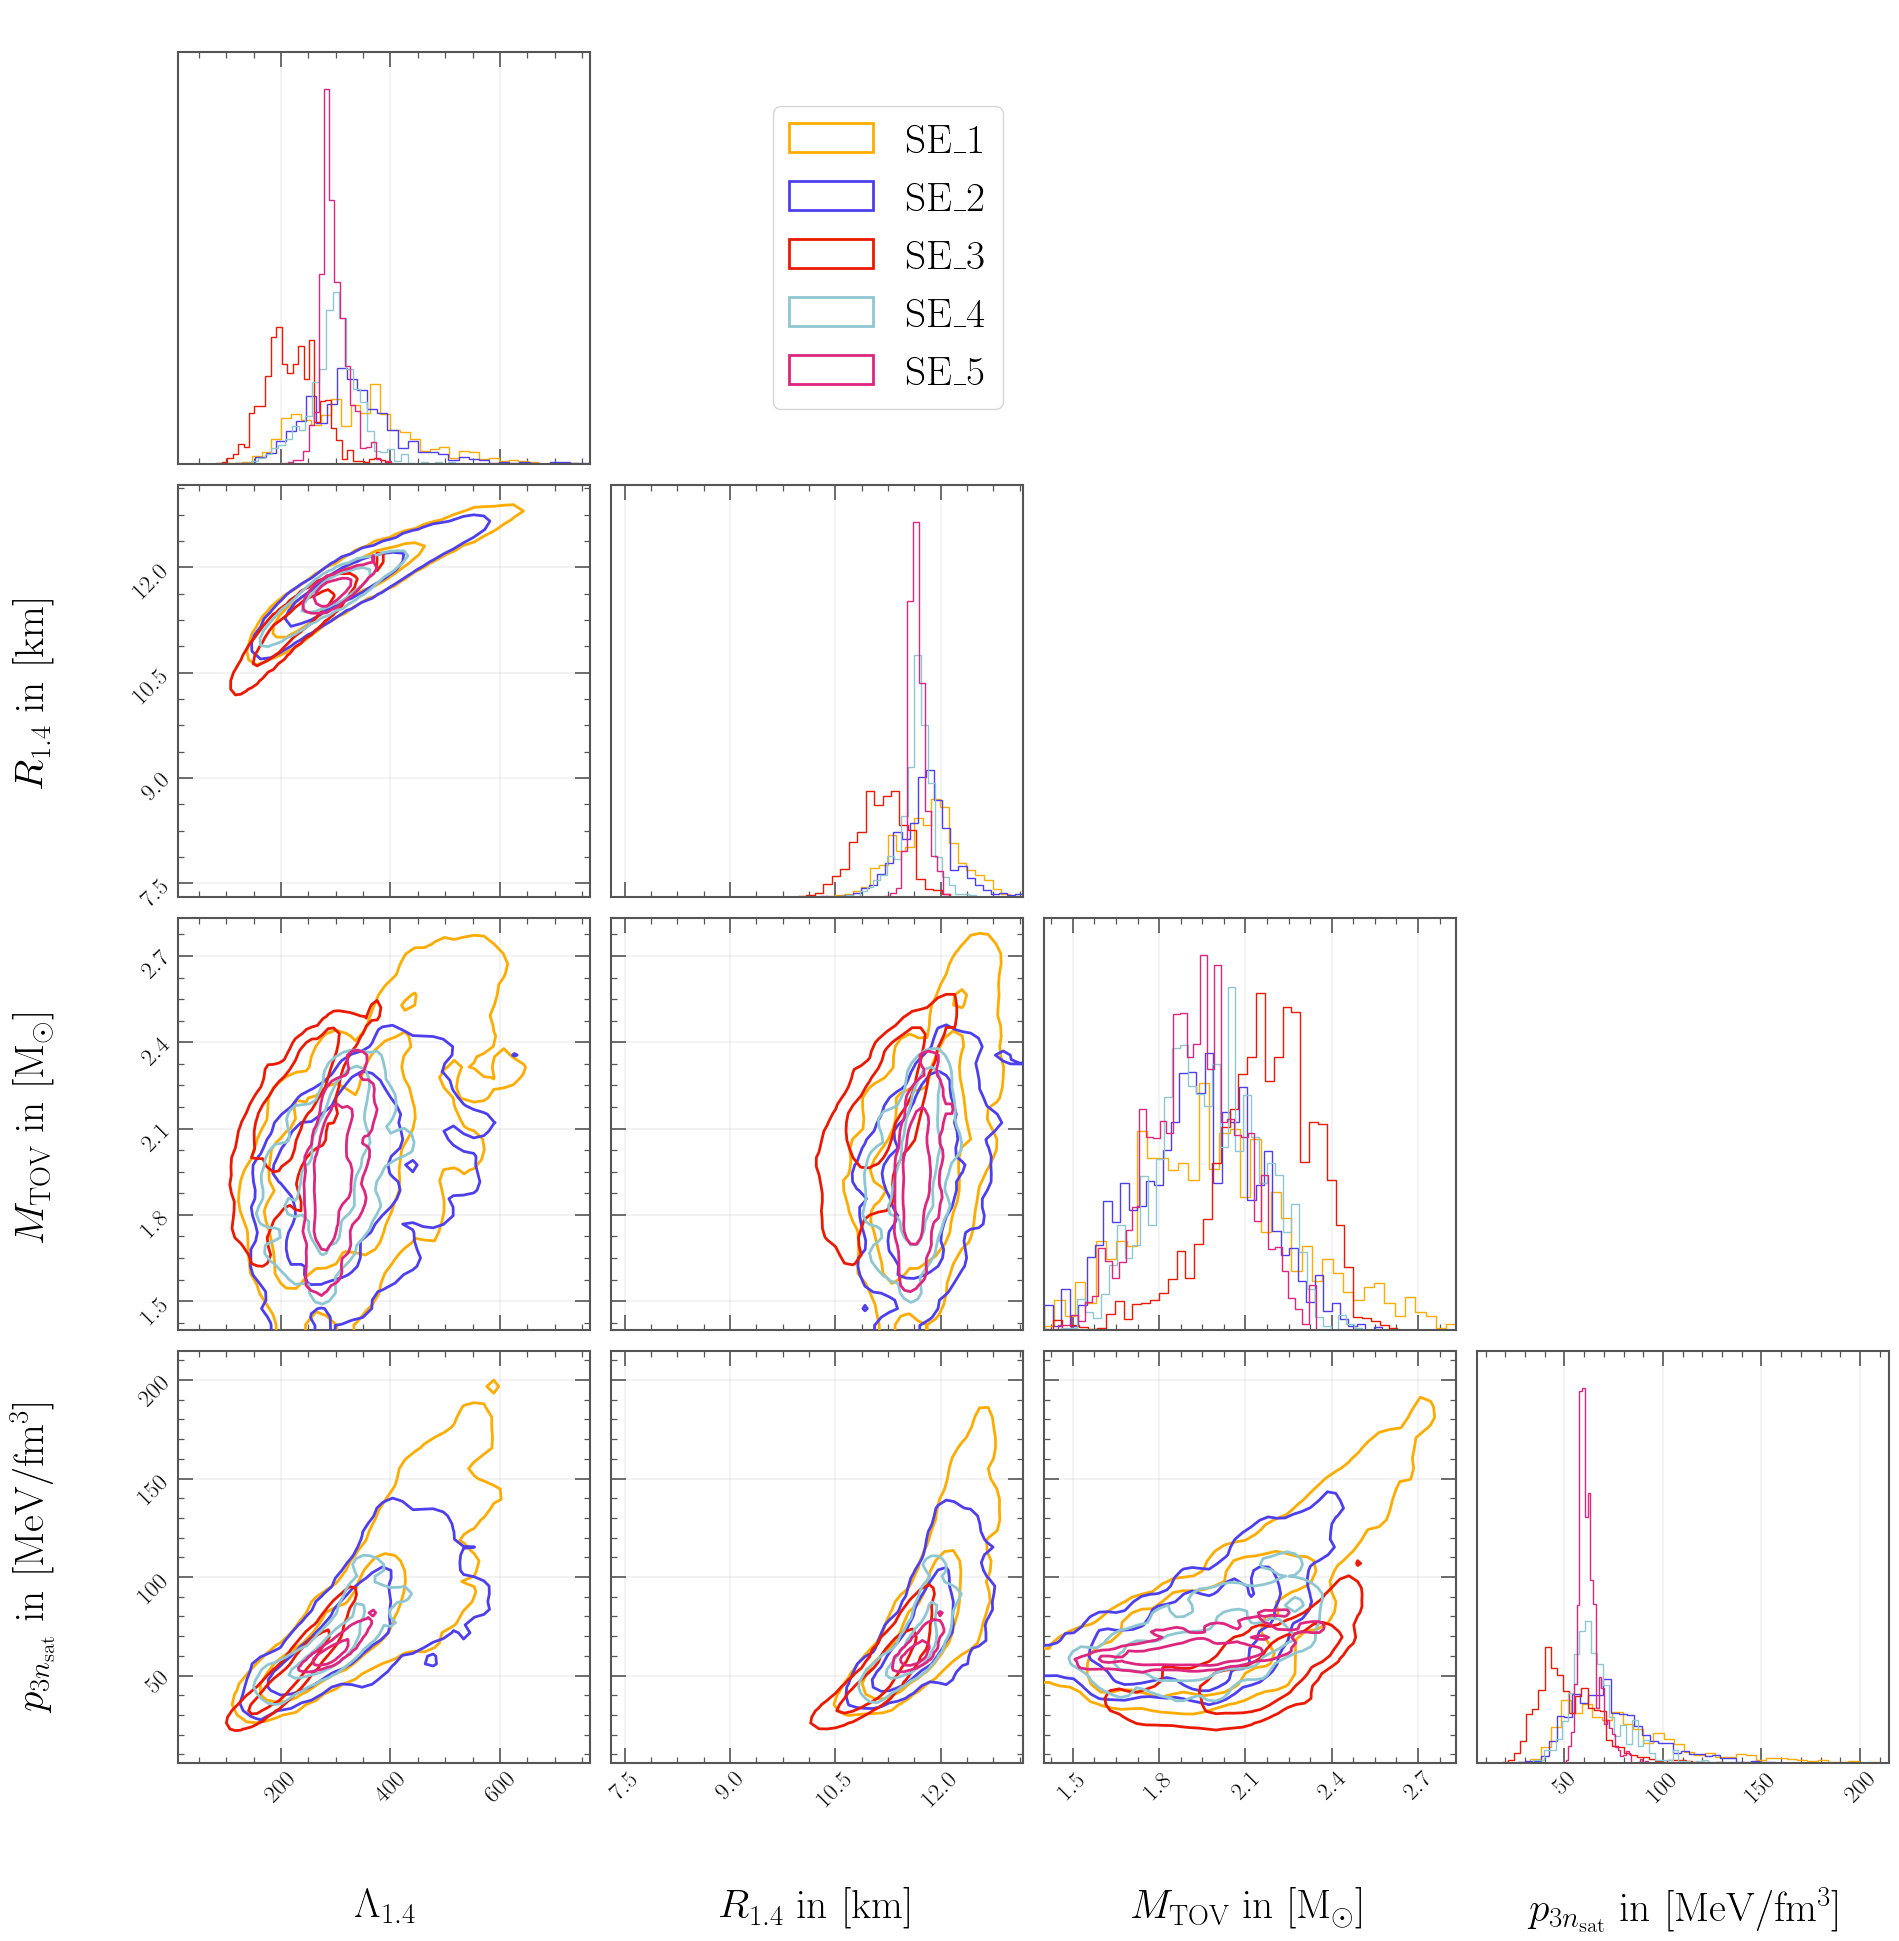

In [ ]:
labs=["SE_1", "SE_2", "SE_3", "SE_4", "SE_5"]
dfs = [df_se, df_se2, df_se3, df_se4, df_se5]
eoses = [eos_se, eos_se2, eos_se3, eos_se4, eos_se5]
mrs = [mr_se, mr_se2, mr_se3, mr_se4, mr_se5]


theme.apply()
pa.plot_parameters(dfs, 
                   title=" ", 
                   colours = cols,
                   labels=labs,
                   contour_fill=False,
                   which=2,
                   legend_fontsize=30,
                   axis_fontsize=30,
                   weighted=True
                )
plt.savefig(plot_dir + "lengthscale_corner_posterior.png", dpi=300)
plt.show()

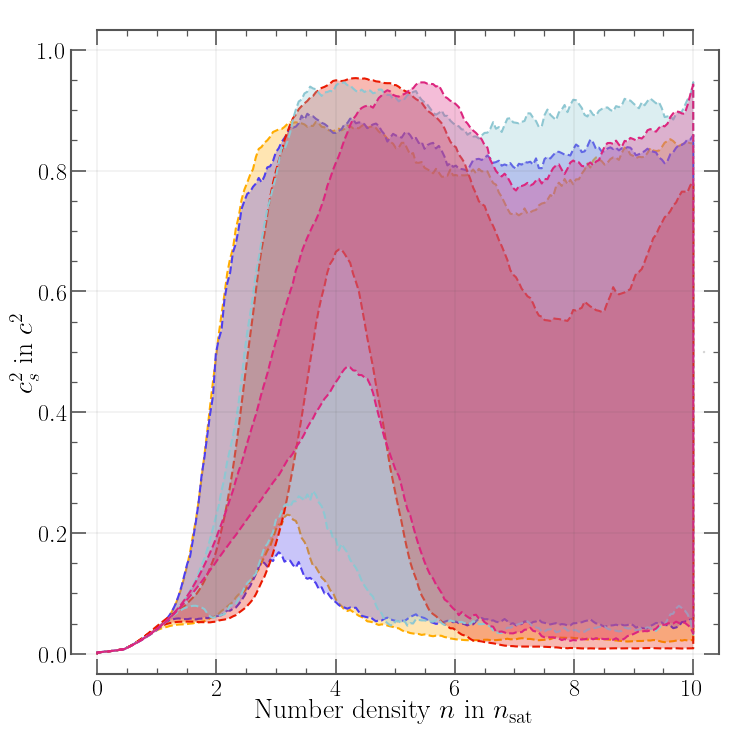

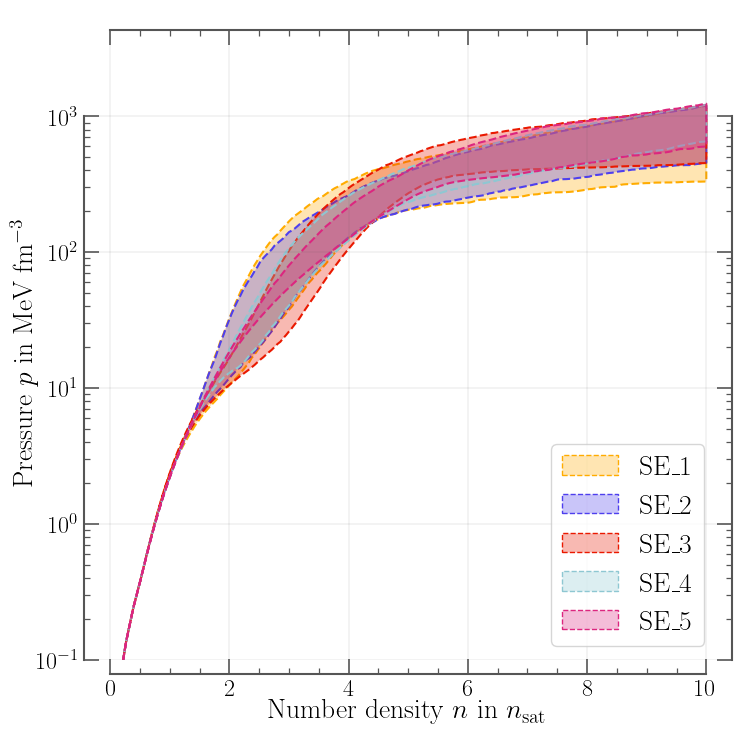

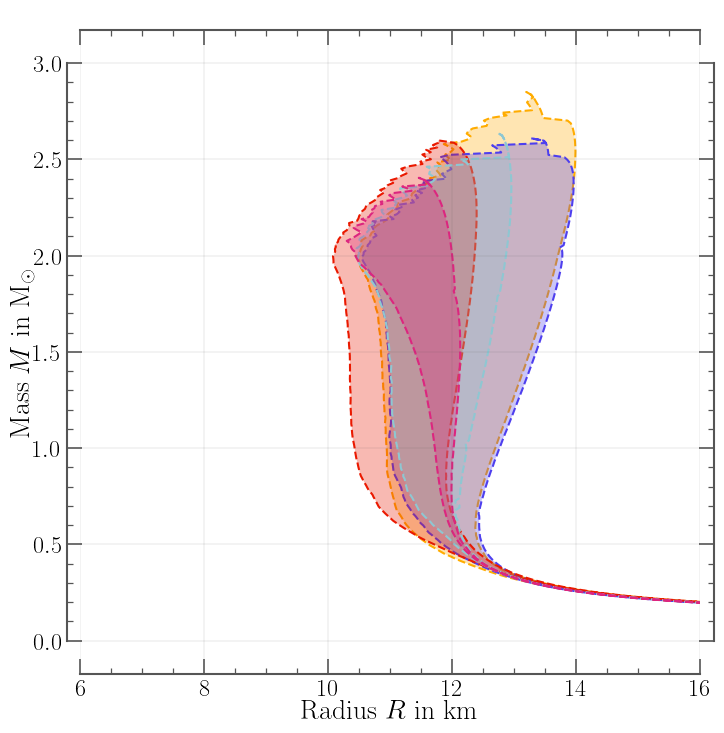

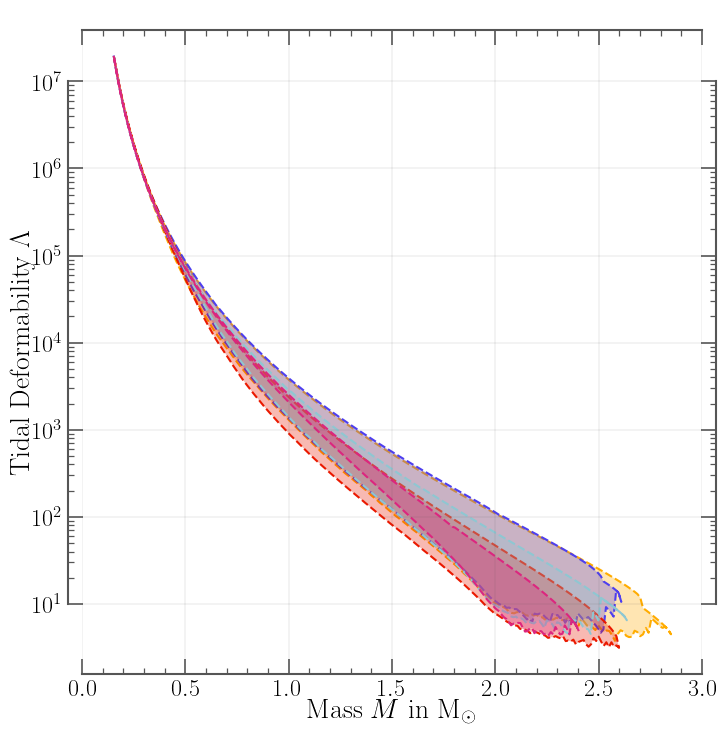

In [44]:
fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se_post,eos_se2_post, eos_se3_post, eos_se4_post, eos_se5_post], ax1=None, ax2=ax1, 
                        mr_list=[mr_se_post, mr_se2_post, mr_se3_post, mr_se4_post, mr_se5_post], 
                        labels=None, colours=cols, plot_alone="cs2", plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_se2, weight_se3, weight_se4, weight_se5])
plt.title(" ")
plt.ylim(-0.01, 1.01)
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "lengthscale_cs2_posterior.png", dpi=300)

plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))
pa.plot_eos_comparisons([eos_se_post,eos_se2_post, eos_se3_post, eos_se4_post, eos_se5_post], ax1=ax1, 
                        mr_list=[mr_se_post, mr_se2_post, mr_se3_post, mr_se4_post, mr_se5_post], 
                        labels=["SE_1", "SE_2", "SE_3", "SE_4", "SE_5"],
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=big_fontsize,
                        weights=[weight_se, weight_se2, weight_se3, weight_se4, weight_se5])


plt.ylim(0.1,)
plt.yscale('log')
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "lengthscale_p_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


plt.plot([], [], color='silver', alpha=1, label='Samples')

pa.plot_eos_comparisons([eos_se_post,eos_se2_post, eos_se3_post, eos_se4_post, eos_se5_post], ax1=None, ax3=ax1, 
                        mr_list=[mr_se_post, mr_se2_post, mr_se3_post, mr_se4_post, mr_se5_post],  
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_se2, weight_se3, weight_se4, weight_se5])

plt.ylim(-0.1, top=3.1)
plt.xlim(6,16)
plt.title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "lengthscale_mr_posterior.png", dpi=300)
plt.show()

fig, ax1 = plt.subplots(1,1, figsize=(8, 8))


pa.plot_eos_comparisons([eos_se_post,eos_se2_post, eos_se3_post, eos_se4_post, eos_se5_post], ax1=None, ax4=ax1, 
                        mr_list=[mr_se_post, mr_se2_post, mr_se3_post, mr_se4_post, mr_se5_post], 
                        colours=cols, plot_mean=False, axis_fontsize=big_fontsize, legend_fontsize=0,
                        weights=[weight_se, weight_se2, weight_se3, weight_se4, weight_se5])

ax1.set_xlim(0, 3)
ax1.set_yscale('log')
ax1.set_title(" ")
theme.apply()
theme.apply_transforms()
plt.savefig(plot_dir + "lengthscale_mt_posterior.png", dpi=300)
plt.show()

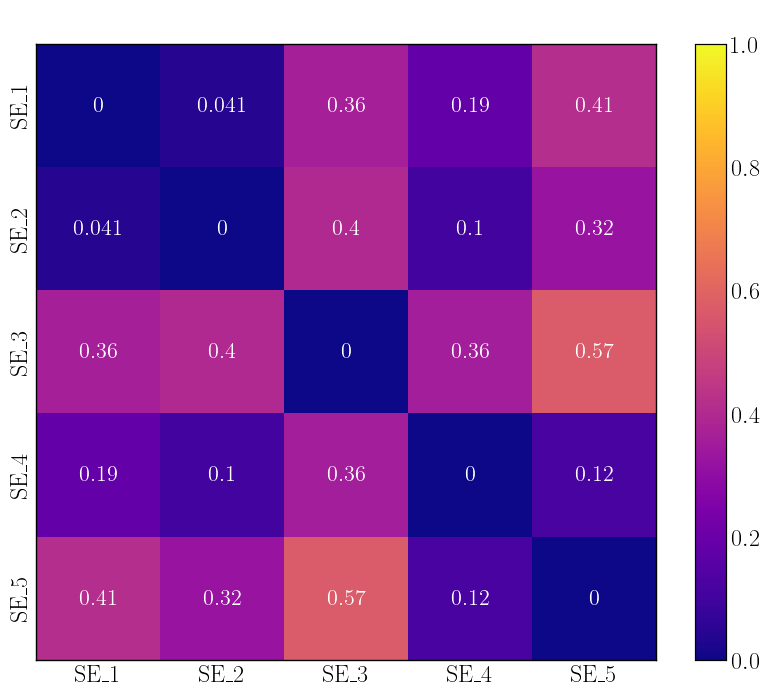

In [45]:
labs=["SE_1", "SE_2", "SE_3", "SE_4", "SE_5"]
dfs = [df_se, df_se2, df_se3, df_se4, df_se5]
theme.set_grid(False)
theme.set_ticks(draw_minor=False, size_major=0)
theme.apply()
pa.plot_JSD('lambda_14', dfs, labs, title=" ", bins=40, weighted=True, size=(10, 8))
plt.savefig(plot_dir + "lengthscale_JSD_posterior.png", dpi=300)
plt.show()
theme.set_grid(True, width=0.2)
theme.set_ticks(draw_minor=True, size_major=11)
theme.apply()

In [ ]:
labs=["SE_1", "SE_2", "SE_3", "SE_4", "SE_5"]
dfs = [df_se, df_se2, df_se3, df_se4, df_se5]
pa.JSD_average('lambda_14', dfs, labs, bins=40, weighted=True) 

Average JSD: 0.28641284202877787


0.28641284202877787

In [7]:
labs=["SE_1", "SE_2", "SE_4"]
dfs = [df_se, df_se2, df_se4]
pa.JSD_average('lambda_14', dfs, True) 

Average JSD: 0.10936433437508401


0.10936433437508401

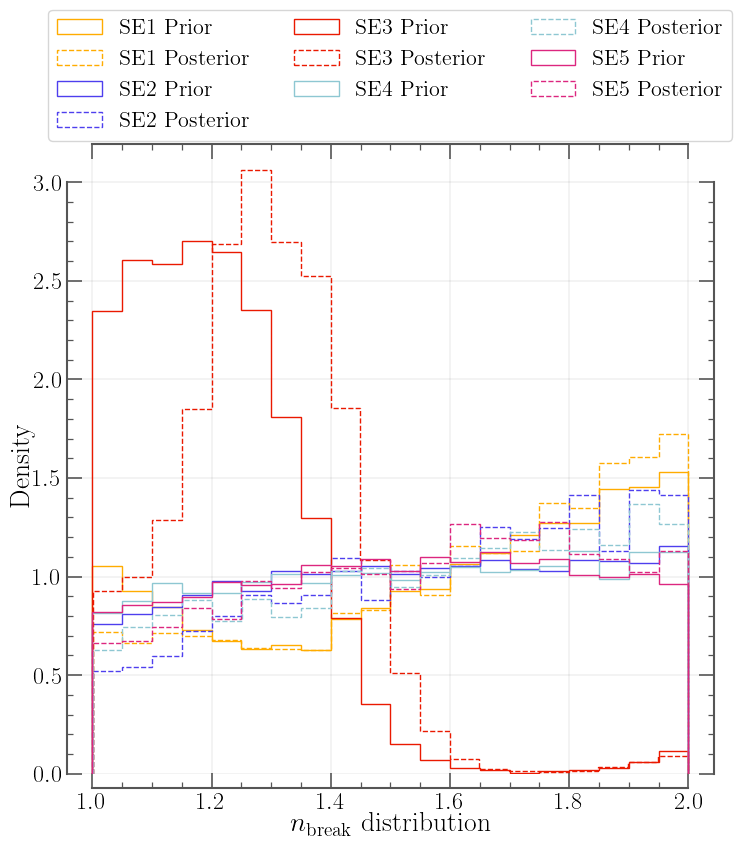

In [ ]:
plt.figure(figsize=(8, 8))
nbreak_plot(['SE_10ns_1', 'SE_10ns_2', 'SE_10ns_3', 'SE_10ns_4', 'SE_10ns_5'], colours=cols, labs=['SE1', 'SE2', 'SE3', 'SE4', 'SE5'], 
            posterior_dfs=[df_se, df_se2, df_se3, df_se4, df_se5],
            plot_prior=True, plot_unif_prior=False, 
            legend_fontsize=big_fontsize, axis_fontsize=big_fontsize)
plt.legend(loc='lower center', fontsize =solo_fontsize, ncols=3)
plt.title(" ")
theme.apply()
theme.apply_transforms()
#plt.savefig(plot_dir + "lengthscale_nbreak_posterior.png", dpi=300)
plt.show()